In [15]:
import tensorflow as tf
import numpy as np
import pandas as pd
import pyfaidx
from collections import Counter, defaultdict, OrderedDict
from copy import deepcopy
from tqdm import tqdm
from tqdm import tnrange
import deepdish
import pyBigWig
import tqdm
import sys
import pyfaidx
#import pysam
sys.path.append("../../../chrombpnet/")
from training.utils.losses import multinomial_nll
from training.utils.one_hot import dna_to_one_hot
from evaluation.interpret.shap_utils import *
import matplotlib as plt
plt.rc('figure', max_open_warning = 0)
import seaborn as sns
import shap
import glob
tf.compat.v1.disable_eager_execution()
import matplotlib.pyplot as plt
import scipy.stats
import pandas as pd
import sklearn.cluster
from scipy.stats import chi2_contingency
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
import pyBigWig
import matplotlib
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import get_custom_objects
import sys
sys.path.append("../../../src/")
custom_objects={"tf":tf, "multinomial_nll":multinomial_nll}    
get_custom_objects().update(custom_objects)
from tensorflow import keras
#import proplot as pplt
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage
#import statsmodels.api as sm
import timeit

In [10]:
custom_cmap = matplotlib.colors.LinearSegmentedColormap.from_list( 'custom',plt.get_cmap('Reds')(np.linspace(0,1,100)**(2)) )

In [11]:
shared_motifs = pd.read_csv("../../zebrafish/mouse_zebra_conserved_motifs_forehindspinal.tsv",header=None)
shared_motifs.columns = ['motif']
shared_motifs = shared_motifs.motif.tolist()

In [12]:
def apply_powerlaw_threshold(df, xcol="Enrichment", ycol="Peak",
                             alpha=3.1, c=0.4,
                             x_min=1.5, y_min=0.003,
                             keep="above"):
    """
    Compare each point in df against power-law cutoff y = c * x^(-alpha).
    Also enforces x >= x_min and y >= y_min if provided.

    keep="above" returns points above the cutoff,
    keep="below" returns points below the cutoff.
    """

    x = df[xcol].to_numpy()
    y = df[ycol].to_numpy()

    # power-law cutoff line evaluated at each x
    y_cut = c * (x ** (-alpha))

    # enforce thresholds
    valid = (x >= x_min) & (y >= y_min)

    if keep == "above":
        mask = valid & (y > y_cut)
    else:
        mask = valid & (y < y_cut)

    df_out = df.copy()
    df_out["y_cutoff"] = y_cut
    df_out["pass_powerlaw"] = mask
    return df_out

## Region peaks with no overlap allowed

### Note that fisher file used has already multiple test corrected


## Mouse

### Forebrain

In [10]:
mouse_fb_enrichment = pd.read_csv("../../mouse/interpret/da_peaks/forehindspinal_filtered/mouse_forebrain_filtered_enrichment_04_20_25_95_74motifs_overlapfiltered.tsv",sep="\t",index_col=0)
mouse_fb_rawpeaks = pd.read_csv("../../mouse/interpret/da_peaks/forehindspinal_filtered/mouse_forebrain_rawfiltered_peakcounts.tsv",sep="\t",index_col=0)
mouse_fb_fisher = pd.read_csv("../../mouse/interpret/da_peaks/forehindspinal_filtered/mouse_forebrain_filtered_fisher_multiple_04_20_25_95_74motifs_overlapfiltered.tsv",sep="\t",index_col=0)

In [11]:
# Raw peaks
mouse_fb_rawpeaks_motif_list = list(mouse_fb_rawpeaks.columns)
mouse_fb_rawpeaks_long = pd.melt(mouse_fb_rawpeaks, value_vars=mouse_fb_rawpeaks_motif_list,value_name='Peak',ignore_index=False).reset_index()
mouse_fb_rawpeaks_long[['motif_1', 'variable']] = pd.DataFrame(mouse_fb_rawpeaks_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=mouse_fb_rawpeaks_long.index)
mouse_fb_rawpeaks_long_final = mouse_fb_rawpeaks_long.drop_duplicates(subset=['motif_1','variable'])
mouse_fb_rawpeaks_long_final = mouse_fb_rawpeaks_long_final.reset_index(drop=True)

# Enrichment 
mouse_fb_enrichment_motif_list = list(mouse_fb_enrichment.columns)
mouse_fb_enrichment_long = pd.melt(mouse_fb_enrichment, value_vars=mouse_fb_enrichment_motif_list,value_name='Enrichment',ignore_index=False).reset_index()
mouse_fb_enrichment_long[['motif_1', 'variable']] = pd.DataFrame(mouse_fb_enrichment_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=mouse_fb_enrichment_long.index)
mouse_fb_enrichment_long_final = mouse_fb_enrichment_long.drop_duplicates(subset=['motif_1','variable'])
mouse_fb_enrichment_long_final = mouse_fb_enrichment_long_final.reset_index(drop=True)

# Fisher
mouse_fb_fisher_motif_list = list(mouse_fb_fisher.columns)
mouse_fb_fisher_long = pd.melt(mouse_fb_fisher, value_vars=mouse_fb_fisher_motif_list,value_name='Fisher',ignore_index=False).reset_index()
mouse_fb_fisher_long[['motif_1', 'variable']] = pd.DataFrame(mouse_fb_fisher_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=mouse_fb_fisher_long.index)
mouse_fb_fisher_long_final = mouse_fb_fisher_long.drop_duplicates(subset=['motif_1','variable'])
mouse_fb_fisher_long_final.loc[mouse_fb_fisher_long_final['motif_1'] == mouse_fb_fisher_long_final['variable'], 'Fisher'] = 1
mouse_fb_fisher_long_final = mouse_fb_fisher_long_final.reset_index(drop=True)

In [12]:
mouse_fb_merged = mouse_fb_rawpeaks_long_final.merge(mouse_fb_enrichment_long_final, on=["motif_1", "variable"], how="outer") \
            .merge(mouse_fb_fisher_long_final, on=["motif_1", "variable"], how="outer") \

mouse_fb_totalpeak = pd.read_csv('../../mouse/interpret/da_peaks/mouse_da_peaks_forebrain_filtered.tsv',index_col=0).shape[0]

mouse_fb_merged['Peak'] = mouse_fb_merged['Peak']/mouse_fb_totalpeak
mouse_fb_filtered = mouse_fb_merged[mouse_fb_merged["motif_1"] != mouse_fb_merged["variable"]]

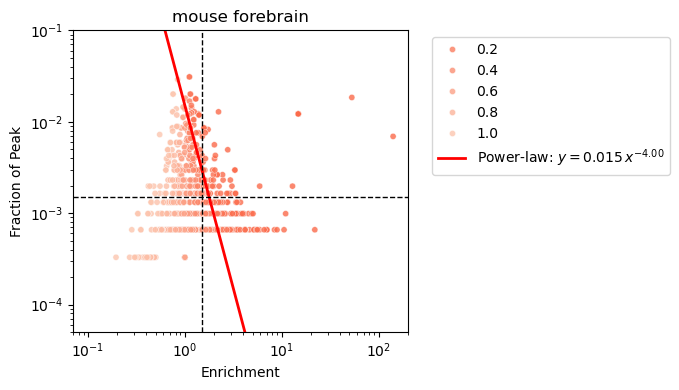

In [69]:
# --- given fit parameters ---
alpha = 4
c = 0.015

custom_red =  matplotlib.colors.LinearSegmentedColormap.from_list(
    "custom_red",
    ["#fb6b4b", "#fcc6af"], N=1000
)
cmap=custom_red

# --- choose x-range for the curve ---
x_min, x_max = 0.1, 100     # <-- you can adjust if needed
y_min, y_max = 3e-3, 1.0   # <-- adjust vertical range to match your data

# generate smooth x grid in log-space
x_line = np.logspace(np.log10(x_min), np.log10(x_max), 400)
y_line = c * (x_line ** (-alpha))



# --- plot ---
plt.figure(figsize=(7,4))
sns.scatterplot(
    data=mouse_fb_filtered,
    x="Enrichment",
    y="Peak",
    hue="Fisher",
    palette=cmap,
    alpha=0.8,
    s=20,
    rasterized=True
)


# overlay the power-law curve
plt.plot(x_line, y_line, lw=2, color="red",
         label=fr"Power-law: $y={c:.3g}\,x^{{-{alpha:.2f}}}$")

# set log axes + limits
plt.xscale("log")
plt.yscale("log")
plt.ylim([0.00005,0.1])

# optional threshold lines
plt.axhline(y=0.0015, color="black", linestyle="--", linewidth=1)
plt.axvline(x=1.5, color="black", linestyle="--", linewidth=1)

plt.xlabel("Enrichment")
plt.ylabel("Fraction of Peak")
plt.title("mouse forebrain")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("./pair_plots/mouse_forebrain_cooccurrence.svg",dpi=600)
plt.show()

In [70]:
mouse_fb_filtered_powerlaw = apply_powerlaw_threshold(
    mouse_fb_filtered,
    xcol="Enrichment", ycol="Peak",
    alpha=4, c=0.015,
    x_min=1.5, y_min=0.0015,
    keep="above"
)

# points that pass
mouse_fb_filtered_passed = mouse_fb_filtered_powerlaw[mouse_fb_filtered_powerlaw["pass_powerlaw"]]
print(f"{len(mouse_fb_filtered_passed)} points passed out of {len(mouse_fb_filtered_powerlaw)}")

54 points passed out of 2556


/tmp/ipykernel_12658/2912361076.py:17: RuntimeWarning: divide by zero encountered in power
  y_cut = c * (x ** (-alpha))


### Hindbrain

In [33]:
mouse_hb_enrichment = pd.read_csv("../../mouse/interpret/da_peaks/forehindspinal_filtered/mouse_hindbrain_filtered_enrichment_04_20_25_95_74motifs_overlapfiltered.tsv",sep="\t",index_col=0)
mouse_hb_rawpeaks = pd.read_csv("../../mouse/interpret/da_peaks/forehindspinal_filtered/mouse_hindbrain_rawfiltered_peakcounts.tsv",sep="\t",index_col=0)
mouse_hb_fisher = pd.read_csv("../../mouse/interpret/da_peaks/forehindspinal_filtered/mouse_hindbrain_filtered_fisher_multiple_04_20_25_95_74motifs_overlapfiltered.tsv",sep="\t",index_col=0)

In [34]:
# Raw peaks
mouse_hb_rawpeaks_motif_list = list(mouse_hb_rawpeaks.columns)
mouse_hb_rawpeaks_long = pd.melt(mouse_hb_rawpeaks, value_vars=mouse_hb_rawpeaks_motif_list,value_name='Peak',ignore_index=False).reset_index()
mouse_hb_rawpeaks_long[['motif_1', 'variable']] = pd.DataFrame(mouse_hb_rawpeaks_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=mouse_hb_rawpeaks_long.index)
mouse_hb_rawpeaks_long_final = mouse_hb_rawpeaks_long.drop_duplicates(subset=['motif_1','variable'])
mouse_hb_rawpeaks_long_final = mouse_hb_rawpeaks_long_final.reset_index(drop=True)

# Enrichment 
mouse_hb_enrichment_motif_list = list(mouse_hb_enrichment.columns)
mouse_hb_enrichment_long = pd.melt(mouse_hb_enrichment, value_vars=mouse_hb_enrichment_motif_list,value_name='Enrichment',ignore_index=False).reset_index()
mouse_hb_enrichment_long[['motif_1', 'variable']] = pd.DataFrame(mouse_hb_enrichment_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=mouse_hb_enrichment_long.index)
mouse_hb_enrichment_long_final = mouse_hb_enrichment_long.drop_duplicates(subset=['motif_1','variable'])
mouse_hb_enrichment_long_final = mouse_hb_enrichment_long_final.reset_index(drop=True)

# Fisher
mouse_hb_fisher_motif_list = list(mouse_hb_fisher.columns)
mouse_hb_fisher_long = pd.melt(mouse_hb_fisher, value_vars=mouse_hb_fisher_motif_list,value_name='Fisher',ignore_index=False).reset_index()
mouse_hb_fisher_long[['motif_1', 'variable']] = pd.DataFrame(mouse_hb_fisher_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=mouse_hb_fisher_long.index)
mouse_hb_fisher_long_final = mouse_hb_fisher_long.drop_duplicates(subset=['motif_1','variable'])
mouse_hb_fisher_long_final.loc[mouse_hb_fisher_long_final['motif_1'] == mouse_hb_fisher_long_final['variable'], 'Fisher'] = 1
mouse_hb_fisher_long_final = mouse_hb_fisher_long_final.reset_index(drop=True)

In [36]:
mouse_hb_merged = mouse_hb_rawpeaks_long_final.merge(mouse_hb_enrichment_long_final, on=["motif_1", "variable"], how="outer") \
            .merge(mouse_hb_fisher_long_final, on=["motif_1", "variable"], how="outer") \

mouse_hb_totalpeak = pd.read_csv('../../mouse/interpret/da_peaks/mouse_da_peaks_hindbrain_filtered.tsv',index_col=0).shape[0]

mouse_hb_merged['Peak'] = mouse_hb_merged['Peak']/mouse_hb_totalpeak
mouse_hb_filtered = mouse_hb_merged[mouse_hb_merged["motif_1"] != mouse_hb_merged["variable"]]

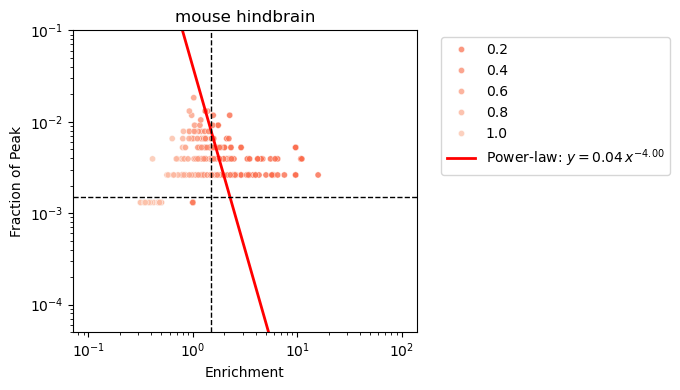

In [56]:
# --- given fit parameters ---
alpha = 4
c = 0.04

# --- choose x-range for the curve ---
x_min, x_max = 0.1, 100     # <-- you can adjust if needed
y_min, y_max = 3e-3, 1.0   # <-- adjust vertical range to match your data

# generate smooth x grid in log-space
x_line = np.logspace(np.log10(x_min), np.log10(x_max), 400)
y_line = c * (x_line ** (-alpha))



# --- plot ---
plt.figure(figsize=(7,4))
sns.scatterplot(
    data=mouse_hb_filtered,
    x="Enrichment",
    y="Peak",
    hue="Fisher",
    palette=cmap,
    alpha=0.8,
    s=20,
    rasterized=True
)


# overlay the power-law curve
plt.plot(x_line, y_line, lw=2, color="red",
         label=fr"Power-law: $y={c:.3g}\,x^{{-{alpha:.2f}}}$")

# set log axes + limits
plt.xscale("log")
plt.yscale("log")
plt.ylim([0.00005,0.1])

# optional threshold lines
plt.axhline(y=0.0015, color="black", linestyle="--", linewidth=1)
plt.axvline(x=1.5, color="black", linestyle="--", linewidth=1)

plt.xlabel("Enrichment")
plt.ylabel("Fraction of Peak")
plt.title("mouse hindbrain")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("./pair_plots/mouse_hindbrain_cooccurrence.svg",dpi=600)

plt.show()

In [38]:
mouse_hb_filtered_powerlaw = apply_powerlaw_threshold(
    mouse_hb_filtered,
    xcol="Enrichment", ycol="Peak",
    alpha=4, c=0.04,
    x_min=1.5, y_min=0.0015,
    keep="above"
)

# points that pass
mouse_hb_filtered_passed = mouse_hb_filtered_powerlaw[mouse_hb_filtered_powerlaw["pass_powerlaw"]]
print(f"{len(mouse_hb_filtered_passed)} points passed out of {len(mouse_hb_filtered_powerlaw)}")

79 points passed out of 2080


/tmp/ipykernel_12658/2912361076.py:17: RuntimeWarning: divide by zero encountered in power
  y_cut = c * (x ** (-alpha))


### Spinal cord

In [39]:
mouse_sc_enrichment = pd.read_csv("../../mouse/interpret/da_peaks/forehindspinal_filtered/mouse_spinal_cord_filtered_enrichment_04_20_25_95_74motifs_overlapfiltered.tsv",sep="\t",index_col=0)
mouse_sc_rawpeaks = pd.read_csv("../../mouse/interpret/da_peaks/forehindspinal_filtered/mouse_spinal_cord_rawfiltered_peakcounts.tsv",sep="\t",index_col=0)
mouse_sc_fisher = pd.read_csv("../../mouse/interpret/da_peaks/forehindspinal_filtered/mouse_spinal_cord_filtered_fisher_multiple_04_20_25_95_74motifs_overlapfiltered.tsv",sep="\t",index_col=0)

In [40]:
# Raw peaks
mouse_sc_rawpeaks_motif_list = list(mouse_sc_rawpeaks.columns)
mouse_sc_rawpeaks_long = pd.melt(mouse_sc_rawpeaks, value_vars=mouse_sc_rawpeaks_motif_list,value_name='Peak',ignore_index=False).reset_index()
mouse_sc_rawpeaks_long[['motif_1', 'variable']] = pd.DataFrame(mouse_sc_rawpeaks_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=mouse_sc_rawpeaks_long.index)
mouse_sc_rawpeaks_long_final = mouse_sc_rawpeaks_long.drop_duplicates(subset=['motif_1','variable'])
mouse_sc_rawpeaks_long_final = mouse_sc_rawpeaks_long_final.reset_index(drop=True)

# Enrichment 
mouse_sc_enrichment_motif_list = list(mouse_sc_enrichment.columns)
mouse_sc_enrichment_long = pd.melt(mouse_sc_enrichment, value_vars=mouse_sc_enrichment_motif_list,value_name='Enrichment',ignore_index=False).reset_index()
mouse_sc_enrichment_long[['motif_1', 'variable']] = pd.DataFrame(mouse_sc_enrichment_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=mouse_sc_enrichment_long.index)
mouse_sc_enrichment_long_final = mouse_sc_enrichment_long.drop_duplicates(subset=['motif_1','variable'])
mouse_sc_enrichment_long_final = mouse_sc_enrichment_long_final.reset_index(drop=True)

# Fisher
mouse_sc_fisher_motif_list = list(mouse_sc_fisher.columns)
mouse_sc_fisher_long = pd.melt(mouse_sc_fisher, value_vars=mouse_sc_fisher_motif_list,value_name='Fisher',ignore_index=False).reset_index()
mouse_sc_fisher_long[['motif_1', 'variable']] = pd.DataFrame(mouse_sc_fisher_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=mouse_sc_fisher_long.index)
mouse_sc_fisher_long_final = mouse_sc_fisher_long.drop_duplicates(subset=['motif_1','variable'])
mouse_sc_fisher_long_final.loc[mouse_sc_fisher_long_final['motif_1'] == mouse_sc_fisher_long_final['variable'], 'Fisher'] = 1
mouse_sc_fisher_long_final = mouse_sc_fisher_long_final.reset_index(drop=True)

In [41]:
mouse_sc_merged = mouse_sc_rawpeaks_long_final.merge(mouse_sc_enrichment_long_final, on=["motif_1", "variable"], how="outer") \
            .merge(mouse_sc_fisher_long_final, on=["motif_1", "variable"], how="outer") \

mouse_sc_totalpeak = pd.read_csv('../../mouse/interpret/da_peaks/mouse_da_peaks_spinal_cord_filtered.tsv',index_col=0).shape[0]

mouse_sc_merged['Peak'] = mouse_sc_merged['Peak']/mouse_sc_totalpeak
mouse_sc_filtered = mouse_sc_merged[mouse_sc_merged["motif_1"] != mouse_sc_merged["variable"]]

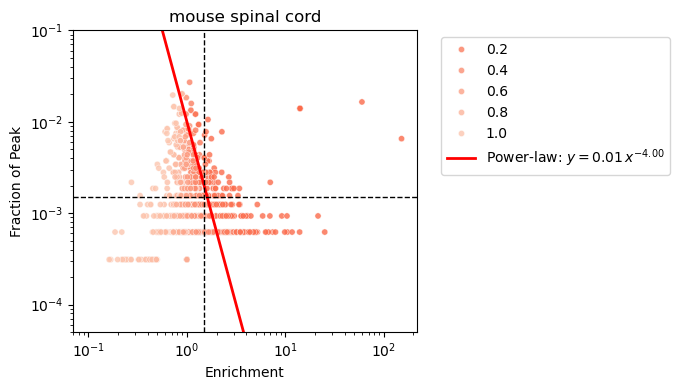

In [57]:
# --- given fit parameters ---
alpha = 4
c = 0.01

# --- choose x-range for the curve ---
x_min, x_max = 0.1, 100     # <-- you can adjust if needed
y_min, y_max = 3e-3, 1.0   # <-- adjust vertical range to match your data

# generate smooth x grid in log-space
x_line = np.logspace(np.log10(x_min), np.log10(x_max), 400)
y_line = c * (x_line ** (-alpha))



# --- plot ---
plt.figure(figsize=(7,4))
sns.scatterplot(
    data=mouse_sc_filtered,
    x="Enrichment",
    y="Peak",
    hue="Fisher",
    palette=cmap,
    alpha=0.8,
    s=20,
    rasterized=True
)


# overlay the power-law curve
plt.plot(x_line, y_line, lw=2, color="red",
         label=fr"Power-law: $y={c:.3g}\,x^{{-{alpha:.2f}}}$")

# set log axes + limits
plt.xscale("log")
plt.yscale("log")
plt.ylim([0.00005,0.1])

# optional threshold lines
plt.axhline(y=0.0015, color="black", linestyle="--", linewidth=1)
plt.axvline(x=1.5, color="black", linestyle="--", linewidth=1)

plt.xlabel("Enrichment")
plt.ylabel("Fraction of Peak")
plt.title("mouse spinal cord")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("./pair_plots/mouse_spinal_cooccurrence.svg",dpi=600)

plt.show()

In [23]:
mouse_sc_filtered_powerlaw = apply_powerlaw_threshold(
    mouse_sc_filtered,
    xcol="Enrichment", ycol="Peak",
    alpha=4, c=0.01,
    x_min=1.5, y_min=0.0015,
    keep="above"
)

# points that pass
mouse_sc_filtered_passed = mouse_sc_filtered_powerlaw[mouse_sc_filtered_powerlaw["pass_powerlaw"]]
print(f"{len(mouse_sc_filtered_passed)} points passed out of {len(mouse_sc_filtered_powerlaw)}")

64 points passed out of 2701


/tmp/ipykernel_12398/2912361076.py:17: RuntimeWarning: divide by zero encountered in power
  y_cut = c * (x ** (-alpha))


### Cell type with no overlap allowed

In [17]:
custom_red =  matplotlib.colors.LinearSegmentedColormap.from_list(
    "custom_red",
    ["#fb6b4b", "#fcc6af"], N=1000
)
cmap=custom_red

In [9]:
mouse_M1_2_enrichment = pd.read_csv("../../mouse/interpret/da_peaks/celltypes/mouse_M1_2_filtered_enrichment_06_24_26_95_74motifs_overlapfiltered.tsv",sep="\t",index_col=0)
mouse_M1_2_rawpeaks = pd.read_csv("../../mouse/interpret/da_peaks/celltypes/mouse_M1_2_rawfiltered_peakcounts.tsv",sep="\t",index_col=0)
mouse_M1_2_fisher = pd.read_csv("../../mouse/interpret/da_peaks/celltypes/mouse_M1_2_filtered_fisher_multiple_06_24_26_95_74motifs_overlapfiltered.tsv",sep="\t",index_col=0)

In [10]:
# Raw peaks
mouse_M1_2_rawpeaks_motif_list = list(mouse_M1_2_rawpeaks.columns)
mouse_M1_2_rawpeaks_long = pd.melt(mouse_M1_2_rawpeaks, value_vars=mouse_M1_2_rawpeaks_motif_list,value_name='Peak',ignore_index=False).reset_index()
mouse_M1_2_rawpeaks_long[['motif_1', 'variable']] = pd.DataFrame(mouse_M1_2_rawpeaks_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=mouse_M1_2_rawpeaks_long.index)
mouse_M1_2_rawpeaks_long_final = mouse_M1_2_rawpeaks_long.drop_duplicates(subset=['motif_1','variable'])
mouse_M1_2_rawpeaks_long_final = mouse_M1_2_rawpeaks_long_final.reset_index(drop=True)

# Enrichment 
mouse_M1_2_enrichment_motif_list = list(mouse_M1_2_enrichment.columns)
mouse_M1_2_enrichment_long = pd.melt(mouse_M1_2_enrichment, value_vars=mouse_M1_2_enrichment_motif_list,value_name='Enrichment',ignore_index=False).reset_index()
mouse_M1_2_enrichment_long[['motif_1', 'variable']] = pd.DataFrame(mouse_M1_2_enrichment_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=mouse_M1_2_enrichment_long.index)
mouse_M1_2_enrichment_long_final = mouse_M1_2_enrichment_long.drop_duplicates(subset=['motif_1','variable'])
mouse_M1_2_enrichment_long_final = mouse_M1_2_enrichment_long_final.reset_index(drop=True)

# Fisher
mouse_M1_2_fisher_motif_list = list(mouse_M1_2_fisher.columns)
mouse_M1_2_fisher_long = pd.melt(mouse_M1_2_fisher, value_vars=mouse_M1_2_fisher_motif_list,value_name='Fisher',ignore_index=False).reset_index()
mouse_M1_2_fisher_long[['motif_1', 'variable']] = pd.DataFrame(mouse_M1_2_fisher_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=mouse_M1_2_fisher_long.index)
mouse_M1_2_fisher_long_final = mouse_M1_2_fisher_long.drop_duplicates(subset=['motif_1','variable'])
mouse_M1_2_fisher_long_final.loc[mouse_M1_2_fisher_long_final['motif_1'] == mouse_M1_2_fisher_long_final['variable'], 'Fisher'] = 1
mouse_M1_2_fisher_long_final = mouse_M1_2_fisher_long_final.reset_index(drop=True)

In [11]:
mouse_M1_2_merged = mouse_M1_2_rawpeaks_long_final.merge(mouse_M1_2_enrichment_long_final, on=["motif_1", "variable"], how="outer") \
            .merge(mouse_M1_2_fisher_long_final, on=["motif_1", "variable"], how="outer") \

mouse_M1_2_totalpeak = pd.read_csv('../../mouse/interpret/da_peaks/mouse_M1_2_peaks.csv',index_col=0).shape[0]

mouse_M1_2_merged['Peak'] = mouse_M1_2_merged['Peak']/mouse_M1_2_totalpeak
mouse_M1_2_filtered = mouse_M1_2_merged[mouse_M1_2_merged["motif_1"] != mouse_M1_2_merged["variable"]]

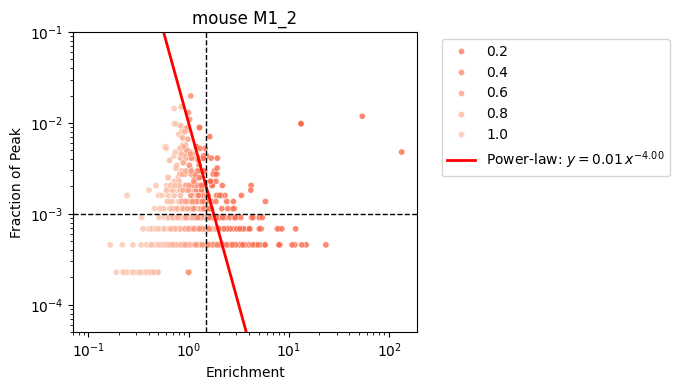

In [21]:
# --- given fit parameters ---
alpha = 4
c = 0.01

# --- choose x-range for the curve ---
x_min, x_max = 0.1, 100     # <-- you can adjust if needed
y_min, y_max = 3e-3, 1.0   # <-- adjust vertical range to match your data

# generate smooth x grid in log-space
x_line = np.logspace(np.log10(x_min), np.log10(x_max), 400)
y_line = c * (x_line ** (-alpha))



# --- plot ---
plt.figure(figsize=(7,4))
sns.scatterplot(
    data=mouse_M1_2_filtered,
    x="Enrichment",
    y="Peak",
    hue="Fisher",
    palette=cmap,
    alpha=0.8,
    s=20,
    rasterized=True
)


# overlay the power-law curve
plt.plot(x_line, y_line, lw=2, color="red",
         label=fr"Power-law: $y={c:.3g}\,x^{{-{alpha:.2f}}}$")

# set log axes + limits
plt.xscale("log")
plt.yscale("log")
plt.ylim([0.00005,0.1])

# optional threshold lines
plt.axhline(y=0.001, color="black", linestyle="--", linewidth=1)
plt.axvline(x=1.5, color="black", linestyle="--", linewidth=1)

plt.xlabel("Enrichment")
plt.ylabel("Fraction of Peak")
plt.title("mouse M1_2")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
#plt.savefig("./pair_plots/mouse_spinal_cooccurrence.svg",dpi=600)

plt.show()

In [22]:
mouse_M1_2_filtered_powerlaw = apply_powerlaw_threshold(
    mouse_M1_2_filtered,
    xcol="Enrichment", ycol="Peak",
    alpha=4, c=0.01,
    x_min=1.5, y_min=0.001,
    keep="above"
)

# points that pass
mouse_M1_2_filtered_passed = mouse_M1_2_filtered_powerlaw[mouse_M1_2_filtered_powerlaw["pass_powerlaw"]]
print(f"{len(mouse_M1_2_filtered_passed)} points passed out of {len(mouse_M1_2_filtered_powerlaw)}")

38 points passed out of 2701


/tmp/ipykernel_20849/2912361076.py:17: RuntimeWarning: divide by zero encountered in power
  y_cut = c * (x ** (-alpha))


### Mouse_0

In [23]:
mouse_0_enrichment = pd.read_csv("../../mouse/interpret/da_peaks/celltypes/mouse_0_filtered_enrichment_06_24_26_95_74motifs_overlapfiltered.tsv",sep="\t",index_col=0)
mouse_0_rawpeaks = pd.read_csv("../../mouse/interpret/da_peaks/celltypes/mouse_0_rawfiltered_peakcounts.tsv",sep="\t",index_col=0)
mouse_0_fisher = pd.read_csv("../../mouse/interpret/da_peaks/celltypes/mouse_0_filtered_fisher_multiple_06_24_26_95_74motifs_overlapfiltered.tsv",sep="\t",index_col=0)

In [24]:
# Raw peaks
mouse_0_rawpeaks_motif_list = list(mouse_0_rawpeaks.columns)
mouse_0_rawpeaks_long = pd.melt(mouse_0_rawpeaks, value_vars=mouse_0_rawpeaks_motif_list,value_name='Peak',ignore_index=False).reset_index()
mouse_0_rawpeaks_long[['motif_1', 'variable']] = pd.DataFrame(mouse_0_rawpeaks_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=mouse_0_rawpeaks_long.index)
mouse_0_rawpeaks_long_final = mouse_0_rawpeaks_long.drop_duplicates(subset=['motif_1','variable'])
mouse_0_rawpeaks_long_final = mouse_0_rawpeaks_long_final.reset_index(drop=True)

# Enrichment 
mouse_0_enrichment_motif_list = list(mouse_0_enrichment.columns)
mouse_0_enrichment_long = pd.melt(mouse_0_enrichment, value_vars=mouse_0_enrichment_motif_list,value_name='Enrichment',ignore_index=False).reset_index()
mouse_0_enrichment_long[['motif_1', 'variable']] = pd.DataFrame(mouse_0_enrichment_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=mouse_0_enrichment_long.index)
mouse_0_enrichment_long_final = mouse_0_enrichment_long.drop_duplicates(subset=['motif_1','variable'])
mouse_0_enrichment_long_final = mouse_0_enrichment_long_final.reset_index(drop=True)

# Fisher
mouse_0_fisher_motif_list = list(mouse_0_fisher.columns)
mouse_0_fisher_long = pd.melt(mouse_0_fisher, value_vars=mouse_0_fisher_motif_list,value_name='Fisher',ignore_index=False).reset_index()
mouse_0_fisher_long[['motif_1', 'variable']] = pd.DataFrame(mouse_0_fisher_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=mouse_0_fisher_long.index)
mouse_0_fisher_long_final = mouse_0_fisher_long.drop_duplicates(subset=['motif_1','variable'])
mouse_0_fisher_long_final.loc[mouse_0_fisher_long_final['motif_1'] == mouse_0_fisher_long_final['variable'], 'Fisher'] = 1
mouse_0_fisher_long_final = mouse_0_fisher_long_final.reset_index(drop=True)

In [25]:
mouse_0_merged = mouse_0_rawpeaks_long_final.merge(mouse_0_enrichment_long_final, on=["motif_1", "variable"], how="outer") \
            .merge(mouse_0_fisher_long_final, on=["motif_1", "variable"], how="outer") \

mouse_0_totalpeak = pd.read_csv('../../mouse/interpret/da_peaks/mouse_0_peaks.csv',index_col=0).shape[0]

mouse_0_merged['Peak'] = mouse_0_merged['Peak']/mouse_0_totalpeak
mouse_0_filtered = mouse_0_merged[mouse_0_merged["motif_1"] != mouse_0_merged["variable"]]

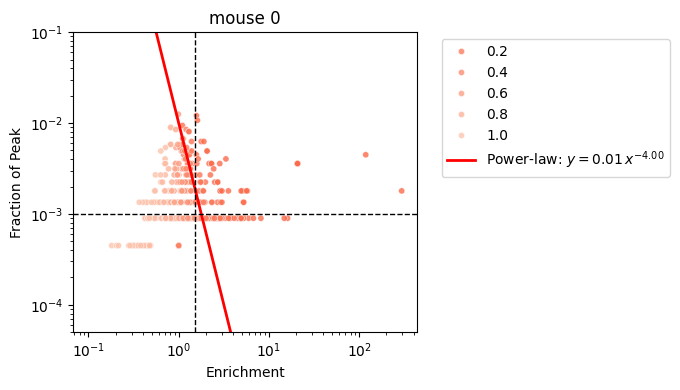

In [37]:
# --- given fit parameters ---
alpha = 4
c = 0.01

# --- choose x-range for the curve ---
x_min, x_max = 0.1, 100     # <-- you can adjust if needed
y_min, y_max = 3e-3, 1.0   # <-- adjust vertical range to match your data

# generate smooth x grid in log-space
x_line = np.logspace(np.log10(x_min), np.log10(x_max), 400)
y_line = c * (x_line ** (-alpha))



# --- plot ---
plt.figure(figsize=(7,4))
sns.scatterplot(
    data=mouse_0_filtered,
    x="Enrichment",
    y="Peak",
    hue="Fisher",
    palette=cmap,
    alpha=0.8,
    s=20,
    rasterized=True
)


# overlay the power-law curve
plt.plot(x_line, y_line, lw=2, color="red",
         label=fr"Power-law: $y={c:.3g}\,x^{{-{alpha:.2f}}}$")

# set log axes + limits
plt.xscale("log")
plt.yscale("log")
plt.ylim([0.00005,0.1])

# optional threshold lines
plt.axhline(y=0.001, color="black", linestyle="--", linewidth=1)
plt.axvline(x=1.5, color="black", linestyle="--", linewidth=1)

plt.xlabel("Enrichment")
plt.ylabel("Fraction of Peak")
plt.title("mouse 0")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
#plt.savefig("./pair_plots/mouse_spinal_cooccurrence.svg",dpi=600)

plt.show()

In [38]:
mouse_0_filtered_powerlaw = apply_powerlaw_threshold(
    mouse_0_filtered,
    xcol="Enrichment", ycol="Peak",
    alpha=4, c=0.01,
    x_min=1.5, y_min=0.001,
    keep="above"
)

# points that pass
mouse_0_filtered_passed = mouse_0_filtered_powerlaw[mouse_0_filtered_powerlaw["pass_powerlaw"]]
print(f"{len(mouse_0_filtered_passed)} points passed out of {len(mouse_0_filtered_powerlaw)}")

57 points passed out of 2556


/tmp/ipykernel_20849/2912361076.py:17: RuntimeWarning: divide by zero encountered in power
  y_cut = c * (x ** (-alpha))


### Mouse_4

In [28]:
mouse_4_enrichment = pd.read_csv("../../mouse/interpret/da_peaks/celltypes/mouse_4_filtered_enrichment_06_24_26_95_74motifs_overlapfiltered.tsv",sep="\t",index_col=0)
mouse_4_rawpeaks = pd.read_csv("../../mouse/interpret/da_peaks/celltypes/mouse_4_rawfiltered_peakcounts.tsv",sep="\t",index_col=0)
mouse_4_fisher = pd.read_csv("../../mouse/interpret/da_peaks/celltypes/mouse_4_filtered_fisher_multiple_06_24_26_95_74motifs_overlapfiltered.tsv",sep="\t",index_col=0)

In [29]:
# Raw peaks
mouse_4_rawpeaks_motif_list = list(mouse_4_rawpeaks.columns)
mouse_4_rawpeaks_long = pd.melt(mouse_4_rawpeaks, value_vars=mouse_4_rawpeaks_motif_list,value_name='Peak',ignore_index=False).reset_index()
mouse_4_rawpeaks_long[['motif_1', 'variable']] = pd.DataFrame(mouse_4_rawpeaks_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=mouse_4_rawpeaks_long.index)
mouse_4_rawpeaks_long_final = mouse_4_rawpeaks_long.drop_duplicates(subset=['motif_1','variable'])
mouse_4_rawpeaks_long_final = mouse_4_rawpeaks_long_final.reset_index(drop=True)

# Enrichment 
mouse_4_enrichment_motif_list = list(mouse_4_enrichment.columns)
mouse_4_enrichment_long = pd.melt(mouse_4_enrichment, value_vars=mouse_4_enrichment_motif_list,value_name='Enrichment',ignore_index=False).reset_index()
mouse_4_enrichment_long[['motif_1', 'variable']] = pd.DataFrame(mouse_4_enrichment_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=mouse_4_enrichment_long.index)
mouse_4_enrichment_long_final = mouse_4_enrichment_long.drop_duplicates(subset=['motif_1','variable'])
mouse_4_enrichment_long_final = mouse_4_enrichment_long_final.reset_index(drop=True)

# Fisher
mouse_4_fisher_motif_list = list(mouse_4_fisher.columns)
mouse_4_fisher_long = pd.melt(mouse_4_fisher, value_vars=mouse_4_fisher_motif_list,value_name='Fisher',ignore_index=False).reset_index()
mouse_4_fisher_long[['motif_1', 'variable']] = pd.DataFrame(mouse_4_fisher_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=mouse_4_fisher_long.index)
mouse_4_fisher_long_final = mouse_4_fisher_long.drop_duplicates(subset=['motif_1','variable'])
mouse_4_fisher_long_final.loc[mouse_4_fisher_long_final['motif_1'] == mouse_4_fisher_long_final['variable'], 'Fisher'] = 1
mouse_4_fisher_long_final = mouse_4_fisher_long_final.reset_index(drop=True)

In [30]:
mouse_4_merged = mouse_4_rawpeaks_long_final.merge(mouse_4_enrichment_long_final, on=["motif_1", "variable"], how="outer") \
            .merge(mouse_4_fisher_long_final, on=["motif_1", "variable"], how="outer") \

mouse_4_totalpeak = pd.read_csv('../../mouse/interpret/da_peaks/mouse_4_peaks.csv',index_col=0).shape[0]

mouse_4_merged['Peak'] = mouse_4_merged['Peak']/mouse_4_totalpeak
mouse_4_filtered = mouse_4_merged[mouse_4_merged["motif_1"] != mouse_4_merged["variable"]]

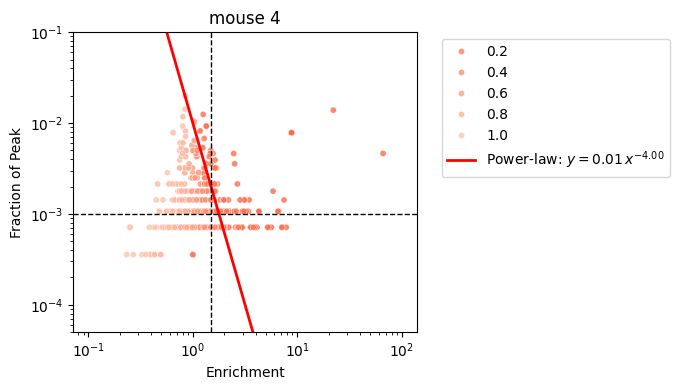

In [32]:
# --- given fit parameters ---
alpha = 4
c = 0.01

# --- choose x-range for the curve ---
x_min, x_max = 0.1, 100     # <-- you can adjust if needed
y_min, y_max = 3e-3, 1.0   # <-- adjust vertical range to match your data

# generate smooth x grid in log-space
x_line = np.logspace(np.log10(x_min), np.log10(x_max), 400)
y_line = c * (x_line ** (-alpha))



# --- plot ---
plt.figure(figsize=(7,4))
sns.scatterplot(
    data=mouse_4_filtered,
    x="Enrichment",
    y="Peak",
    hue="Fisher",
    palette=cmap,
    alpha=0.8,
    s=20,
    rasterized=True
)


# overlay the power-law curve
plt.plot(x_line, y_line, lw=2, color="red",
         label=fr"Power-law: $y={c:.3g}\,x^{{-{alpha:.2f}}}$")

# set log axes + limits
plt.xscale("log")
plt.yscale("log")
plt.ylim([0.00005,0.1])

# optional threshold lines
plt.axhline(y=0.001, color="black", linestyle="--", linewidth=1)
plt.axvline(x=1.5, color="black", linestyle="--", linewidth=1)

plt.xlabel("Enrichment")
plt.ylabel("Fraction of Peak")
plt.title("mouse 4")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
#plt.savefig("./pair_plots/mouse_spinal_cooccurrence.svg",dpi=600)

plt.show()

In [36]:
mouse_4_filtered_powerlaw = apply_powerlaw_threshold(
    mouse_4_filtered,
    xcol="Enrichment", ycol="Peak",
    alpha=4, c=0.01,
    x_min=1.5, y_min=0.001,
    keep="above"
)

# points that pass
mouse_4_filtered_passed = mouse_4_filtered_powerlaw[mouse_4_filtered_powerlaw["pass_powerlaw"]]
print(f"{len(mouse_4_filtered_passed)} points passed out of {len(mouse_4_filtered_powerlaw)}")

58 points passed out of 2415


/tmp/ipykernel_20849/2912361076.py:17: RuntimeWarning: divide by zero encountered in power
  y_cut = c * (x ** (-alpha))


## Zebrafish

In [43]:
zebra_fb_enrichment = pd.read_csv("../../zebrafish/interpret/da_peaks/forehindspinal_filtered/zebrafish_forebrain_filtered_enrichment_04_20_25_95_74motifs_overlapfiltered.tsv",sep="\t",index_col=0)
zebra_fb_rawpeaks = pd.read_csv("../../zebrafish/interpret/da_peaks/forehindspinal_filtered/zebrafish_forebrain_rawfiltered_peakcounts.tsv",sep="\t",index_col=0)
zebra_fb_fisher = pd.read_csv("../../zebrafish/interpret/da_peaks/forehindspinal_filtered/zebrafish_forebrain_filtered_fisher_multiple_04_20_25_95_74motifs_overlapfiltered.tsv",sep="\t",index_col=0)

In [44]:
# Raw peaks
zebra_fb_rawpeaks_motif_list = list(zebra_fb_rawpeaks.columns)
zebra_fb_rawpeaks_long = pd.melt(zebra_fb_rawpeaks, value_vars=zebra_fb_rawpeaks_motif_list,value_name='Peak',ignore_index=False).reset_index()
zebra_fb_rawpeaks_long[['motif_1', 'variable']] = pd.DataFrame(zebra_fb_rawpeaks_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=zebra_fb_rawpeaks_long.index)
zebra_fb_rawpeaks_long_final = zebra_fb_rawpeaks_long.drop_duplicates(subset=['motif_1','variable'])
zebra_fb_rawpeaks_long_final = zebra_fb_rawpeaks_long_final.reset_index(drop=True)

# Enrichment 
zebra_fb_enrichment_motif_list = list(zebra_fb_enrichment.columns)
zebra_fb_enrichment_long = pd.melt(zebra_fb_enrichment, value_vars=zebra_fb_enrichment_motif_list,value_name='Enrichment',ignore_index=False).reset_index()
zebra_fb_enrichment_long[['motif_1', 'variable']] = pd.DataFrame(zebra_fb_enrichment_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=zebra_fb_enrichment_long.index)
zebra_fb_enrichment_long_final = zebra_fb_enrichment_long.drop_duplicates(subset=['motif_1','variable'])
zebra_fb_enrichment_long_final = zebra_fb_enrichment_long_final.reset_index(drop=True)

# Fisher
zebra_fb_fisher_motif_list = list(zebra_fb_fisher.columns)
zebra_fb_fisher_long = pd.melt(zebra_fb_fisher, value_vars=zebra_fb_fisher_motif_list,value_name='Fisher',ignore_index=False).reset_index()
zebra_fb_fisher_long[['motif_1', 'variable']] = pd.DataFrame(zebra_fb_fisher_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=zebra_fb_fisher_long.index)
zebra_fb_fisher_long_final = zebra_fb_fisher_long.drop_duplicates(subset=['motif_1','variable'])
zebra_fb_fisher_long_final.loc[zebra_fb_fisher_long_final['motif_1'] == zebra_fb_fisher_long_final['variable'], 'Fisher'] = 1
zebra_fb_fisher_long_final = zebra_fb_fisher_long_final.reset_index(drop=True)

In [45]:
zebra_fb_merged = zebra_fb_rawpeaks_long_final.merge(zebra_fb_enrichment_long_final, on=["motif_1", "variable"], how="outer") \
            .merge(zebra_fb_fisher_long_final, on=["motif_1", "variable"], how="outer") \

zebra_fb_totalpeak = pd.read_csv('../../zebrafish/interpret/da_peaks/zebra_da_peaks_forebrain_filtered.tsv',index_col=0).shape[0]

zebra_fb_merged['Peak'] = zebra_fb_merged['Peak']/zebra_fb_totalpeak
zebra_fb_filtered = zebra_fb_merged[zebra_fb_merged["motif_1"] != zebra_fb_merged["variable"]]

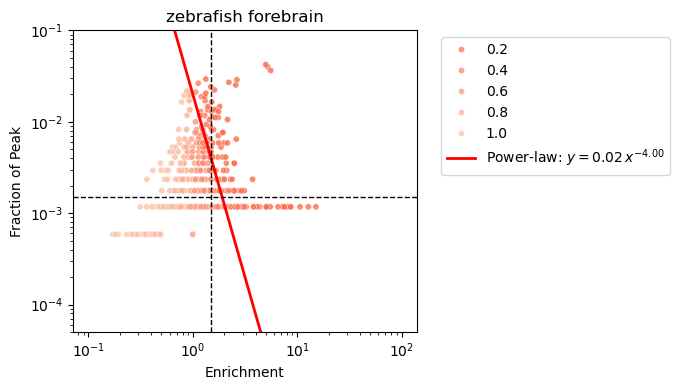

In [65]:
# --- given fit parameters ---
alpha = 4
c = 0.02

# --- choose x-range for the curve ---
x_min, x_max = 0.1, 100     # <-- you can adjust if needed
y_min, y_max = 3e-3, 1.0   # <-- adjust vertical range to match your data

# generate smooth x grid in log-space
x_line = np.logspace(np.log10(x_min), np.log10(x_max), 400)
y_line = c * (x_line ** (-alpha))



# --- plot ---
plt.figure(figsize=(7,4))
sns.scatterplot(
    data=zebra_fb_filtered,
    x="Enrichment",
    y="Peak",
    hue="Fisher",
    palette=cmap,
    alpha=0.8,
    s=20,
    rasterized=True
)


# overlay the power-law curve
plt.plot(x_line, y_line, lw=2, color="red",
         label=fr"Power-law: $y={c:.3g}\,x^{{-{alpha:.2f}}}$")

# set log axes + limits
plt.xscale("log")
plt.yscale("log")
plt.ylim([0.00005,0.1])

# optional threshold lines
plt.axhline(y=0.0015, color="black", linestyle="--", linewidth=1)
plt.axvline(x=1.5, color="black", linestyle="--", linewidth=1)

plt.xlabel("Enrichment")
plt.ylabel("Fraction of Peak")
plt.title("zebrafish forebrain")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("./pair_plots/zebrafish_forebrain_cooccurrence.svg", dpi=600)

plt.show()

In [68]:
zebra_fb_filtered_powerlaw = apply_powerlaw_threshold(
    zebra_fb_filtered,
    xcol="Enrichment", ycol="Peak",
    alpha=4, c=0.02,
    x_min=1.5, y_min=0.0015,
    keep="above"
)

# points that pass
zebra_fb_filtered_passed = zebra_fb_filtered_powerlaw[zebra_fb_filtered_powerlaw["pass_powerlaw"]]
print(f"{len(zebra_fb_filtered_passed)} points passed out of {len(zebra_fb_filtered_powerlaw)}")

59 points passed out of 2278


/tmp/ipykernel_12658/2912361076.py:17: RuntimeWarning: divide by zero encountered in power
  y_cut = c * (x ** (-alpha))


### Hindbrain

In [47]:
zebra_hb_enrichment = pd.read_csv("../../zebrafish/interpret/da_peaks/forehindspinal_filtered/zebrafish_hindbrain_filtered_enrichment_04_20_25_95_74motifs_overlapfiltered.tsv",sep="\t",index_col=0)
zebra_hb_rawpeaks = pd.read_csv("../../zebrafish/interpret/da_peaks/forehindspinal_filtered/zebrafish_hindbrain_rawfiltered_peakcounts.tsv",sep="\t",index_col=0)
zebra_hb_fisher = pd.read_csv("../../zebrafish/interpret/da_peaks/forehindspinal_filtered/zebrafish_hindbrain_filtered_fisher_multiple_04_20_25_95_74motifs_overlapfiltered.tsv",sep="\t",index_col=0)

In [48]:
# Raw peaks
zebra_hb_rawpeaks_motif_list = list(zebra_hb_rawpeaks.columns)
zebra_hb_rawpeaks_long = pd.melt(zebra_hb_rawpeaks, value_vars=zebra_hb_rawpeaks_motif_list,value_name='Peak',ignore_index=False).reset_index()
zebra_hb_rawpeaks_long[['motif_1', 'variable']] = pd.DataFrame(zebra_hb_rawpeaks_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=zebra_hb_rawpeaks_long.index)
zebra_hb_rawpeaks_long_final = zebra_hb_rawpeaks_long.drop_duplicates(subset=['motif_1','variable'])
zebra_hb_rawpeaks_long_final = zebra_hb_rawpeaks_long_final.reset_index(drop=True)

# Enrichment 
zebra_hb_enrichment_motif_list = list(zebra_hb_enrichment.columns)
zebra_hb_enrichment_long = pd.melt(zebra_hb_enrichment, value_vars=zebra_hb_enrichment_motif_list,value_name='Enrichment',ignore_index=False).reset_index()
zebra_hb_enrichment_long[['motif_1', 'variable']] = pd.DataFrame(zebra_hb_enrichment_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=zebra_hb_enrichment_long.index)
zebra_hb_enrichment_long_final = zebra_hb_enrichment_long.drop_duplicates(subset=['motif_1','variable'])
zebra_hb_enrichment_long_final = zebra_hb_enrichment_long_final.reset_index(drop=True)

# Fisher
zebra_hb_fisher_motif_list = list(zebra_hb_fisher.columns)
zebra_hb_fisher_long = pd.melt(zebra_hb_fisher, value_vars=zebra_hb_fisher_motif_list,value_name='Fisher',ignore_index=False).reset_index()
zebra_hb_fisher_long[['motif_1', 'variable']] = pd.DataFrame(zebra_hb_fisher_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=zebra_hb_fisher_long.index)
zebra_hb_fisher_long_final = zebra_hb_fisher_long.drop_duplicates(subset=['motif_1','variable'])
zebra_hb_fisher_long_final.loc[zebra_hb_fisher_long_final['motif_1'] == zebra_hb_fisher_long_final['variable'], 'Fisher'] = 1
zebra_hb_fisher_long_final = zebra_hb_fisher_long_final.reset_index(drop=True)

In [49]:
zebra_hb_merged = zebra_hb_rawpeaks_long_final.merge(zebra_hb_enrichment_long_final, on=["motif_1", "variable"], how="outer") \
            .merge(zebra_hb_fisher_long_final, on=["motif_1", "variable"], how="outer") \

zebra_hb_totalpeak = pd.read_csv('../../zebrafish/interpret/da_peaks/zebra_da_peaks_hindbrain_filtered.tsv',index_col=0).shape[0]

zebra_hb_merged['Peak'] = zebra_hb_merged['Peak']/zebra_hb_totalpeak
zebra_hb_filtered = zebra_hb_merged[zebra_hb_merged["motif_1"] != zebra_hb_merged["variable"]]

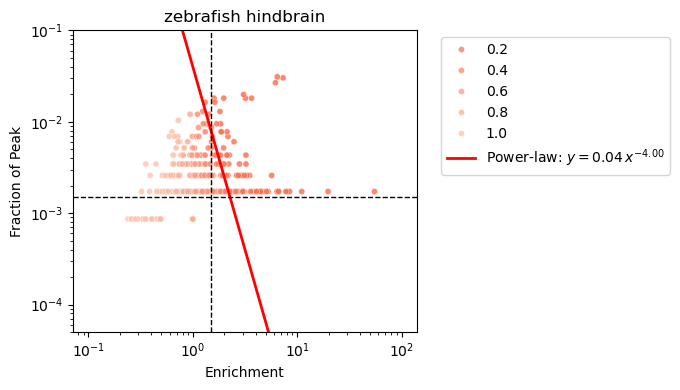

In [62]:
# --- given fit parameters ---
alpha = 4
c = 0.04

# --- choose x-range for the curve ---
x_min, x_max = 0.1, 100     # <-- you can adjust if needed
y_min, y_max = 3e-3, 1.0   # <-- adjust vertical range to match your data

# generate smooth x grid in log-space
x_line = np.logspace(np.log10(x_min), np.log10(x_max), 400)
y_line = c * (x_line ** (-alpha))



# --- plot ---
plt.figure(figsize=(7,4))
sns.scatterplot(
    data=zebra_hb_filtered,
    x="Enrichment",
    y="Peak",
    hue="Fisher",
    palette=cmap,
    alpha=0.8,
    s=20,
    rasterized=True
)


# overlay the power-law curve
plt.plot(x_line, y_line, lw=2, color="red",
         label=fr"Power-law: $y={c:.3g}\,x^{{-{alpha:.2f}}}$")

# set log axes + limits
plt.xscale("log")
plt.yscale("log")
plt.ylim([0.00005,0.1])

# optional threshold lines
plt.axhline(y=0.0015, color="black", linestyle="--", linewidth=1)
plt.axvline(x=1.5, color="black", linestyle="--", linewidth=1)

plt.xlabel("Enrichment")
plt.ylabel("Fraction of Peak")
plt.title("zebrafish hindbrain")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig("./pair_plots/zebra_hindbrain_cooccurrence.svg",dpi=600)

plt.show()

In [33]:
zebra_hb_filtered_powerlaw = apply_powerlaw_threshold(
    zebra_hb_filtered,
    xcol="Enrichment", ycol="Peak",
    alpha=4, c=0.04,
    x_min=1.5, y_min=0.0015,
    keep="above"
)

# points that pass
zebra_hb_filtered_passed = zebra_hb_filtered_powerlaw[zebra_hb_filtered_powerlaw["pass_powerlaw"]]
print(f"{len(zebra_hb_filtered_passed)} points passed out of {len(zebra_hb_filtered_powerlaw)}")

73 points passed out of 2278


/tmp/ipykernel_12398/2912361076.py:17: RuntimeWarning: divide by zero encountered in power
  y_cut = c * (x ** (-alpha))


### Spinal cord

In [51]:
zebra_sc_enrichment = pd.read_csv("../../zebrafish/interpret/da_peaks/forehindspinal_filtered/zebrafish_spinal_cord_filtered_enrichment_04_20_25_95_74motifs_overlapfiltered.tsv",sep="\t",index_col=0)
zebra_sc_rawpeaks = pd.read_csv("../../zebrafish/interpret/da_peaks/forehindspinal_filtered/zebrafish_spinal_cord_rawfiltered_peakcounts.tsv",sep="\t",index_col=0)
zebra_sc_fisher = pd.read_csv("../../zebrafish/interpret/da_peaks/forehindspinal_filtered/zebrafish_spinal_cord_filtered_fisher_multiple_04_20_25_95_74motifs_overlapfiltered.tsv",sep="\t",index_col=0)

In [52]:
# Raw peaks
zebra_sc_rawpeaks_motif_list = list(zebra_sc_rawpeaks.columns)
zebra_sc_rawpeaks_long = pd.melt(zebra_sc_rawpeaks, value_vars=zebra_sc_rawpeaks_motif_list,value_name='Peak',ignore_index=False).reset_index()
zebra_sc_rawpeaks_long[['motif_1', 'variable']] = pd.DataFrame(zebra_sc_rawpeaks_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=zebra_sc_rawpeaks_long.index)
zebra_sc_rawpeaks_long_final = zebra_sc_rawpeaks_long.drop_duplicates(subset=['motif_1','variable'])
zebra_sc_rawpeaks_long_final = zebra_sc_rawpeaks_long_final.reset_index(drop=True)

# Enrichment 
zebra_sc_enrichment_motif_list = list(zebra_sc_enrichment.columns)
zebra_sc_enrichment_long = pd.melt(zebra_sc_enrichment, value_vars=zebra_sc_enrichment_motif_list,value_name='Enrichment',ignore_index=False).reset_index()
zebra_sc_enrichment_long[['motif_1', 'variable']] = pd.DataFrame(zebra_sc_enrichment_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=zebra_sc_enrichment_long.index)
zebra_sc_enrichment_long_final = zebra_sc_enrichment_long.drop_duplicates(subset=['motif_1','variable'])
zebra_sc_enrichment_long_final = zebra_sc_enrichment_long_final.reset_index(drop=True)

# Fisher
zebra_sc_fisher_motif_list = list(zebra_sc_fisher.columns)
zebra_sc_fisher_long = pd.melt(zebra_sc_fisher, value_vars=zebra_sc_fisher_motif_list,value_name='Fisher',ignore_index=False).reset_index()
zebra_sc_fisher_long[['motif_1', 'variable']] = pd.DataFrame(zebra_sc_fisher_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=zebra_sc_fisher_long.index)
zebra_sc_fisher_long_final = zebra_sc_fisher_long.drop_duplicates(subset=['motif_1','variable'])
zebra_sc_fisher_long_final.loc[zebra_sc_fisher_long_final['motif_1'] == zebra_sc_fisher_long_final['variable'], 'Fisher'] = 1
zebra_sc_fisher_long_final = zebra_sc_fisher_long_final.reset_index(drop=True)

In [53]:
zebra_sc_merged = zebra_sc_rawpeaks_long_final.merge(zebra_sc_enrichment_long_final, on=["motif_1", "variable"], how="outer") \
            .merge(zebra_sc_fisher_long_final, on=["motif_1", "variable"], how="outer") \

zebra_sc_totalpeak = pd.read_csv('../../zebrafish/interpret/da_peaks/zebra_da_peaks_spinal_cord_filtered.tsv',index_col=0).shape[0]

zebra_sc_merged['Peak'] = zebra_sc_merged['Peak']/zebra_sc_totalpeak
zebra_sc_filtered = zebra_sc_merged[zebra_sc_merged["motif_1"] != zebra_sc_merged["variable"]]

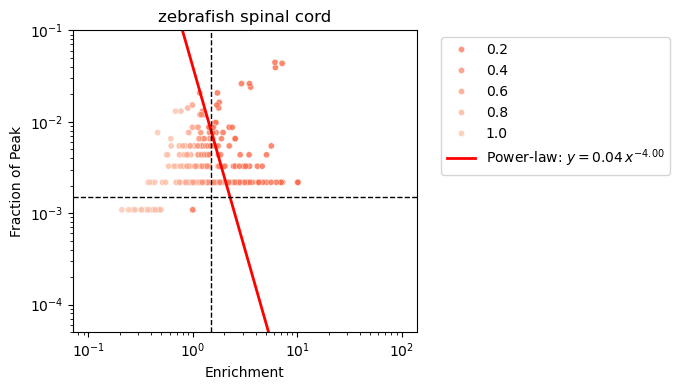

In [61]:
# --- given fit parameters ---
alpha = 4
c = 0.04

# --- choose x-range for the curve ---
x_min, x_max = 0.1, 100     # <-- you can adjust if needed
y_min, y_max = 3e-3, 1.0   # <-- adjust vertical range to match your data

# generate smooth x grid in log-space
x_line = np.logspace(np.log10(x_min), np.log10(x_max), 400)
y_line = c * (x_line ** (-alpha))



# --- plot ---
plt.figure(figsize=(7,4))
sns.scatterplot(
    data=zebra_sc_filtered,
    x="Enrichment",
    y="Peak",
    hue="Fisher",
    palette=cmap,
    alpha=0.8,
    s=20,
    rasterized=True
)


# overlay the power-law curve
plt.plot(x_line, y_line, lw=2, color="red",
         label=fr"Power-law: $y={c:.3g}\,x^{{-{alpha:.2f}}}$")

# set log axes + limits
plt.xscale("log")
plt.yscale("log")
plt.ylim([0.00005,0.1])

# optional threshold lines
plt.axhline(y=0.0015, color="black", linestyle="--", linewidth=1)
plt.axvline(x=1.5, color="black", linestyle="--", linewidth=1)

plt.xlabel("Enrichment")
plt.ylabel("Fraction of Peak")
plt.title("zebrafish spinal cord")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig("./pair_plots/zebra_spinal_cooccurrence.svg",dpi=600)

plt.show()

In [38]:
zebra_sc_filtered_powerlaw = apply_powerlaw_threshold(
    zebra_sc_filtered,
    xcol="Enrichment", ycol="Peak",
    alpha=4, c=0.04,
    x_min=1.5, y_min=0.0015,
    keep="above"
)

# points that pass
zebra_sc_filtered_passed = zebra_sc_filtered_powerlaw[zebra_sc_filtered_powerlaw["pass_powerlaw"]]
print(f"{len(zebra_sc_filtered_passed)} points passed out of {len(zebra_sc_filtered_powerlaw)}")

82 points passed out of 2211


/tmp/ipykernel_12398/2912361076.py:17: RuntimeWarning: divide by zero encountered in power
  y_cut = c * (x ** (-alpha))


## Cell type

### M5_12

In [2]:
zebra_M5_12_enrichment = pd.read_csv("../../zebrafish/interpret/da_peaks/celltype/zebrafish_M5_12_filtered_enrichment_06_24_26_95_74motifs_overlapfiltered.tsv",sep="\t",index_col=0)
zebra_M5_12_rawpeaks = pd.read_csv("../../zebrafish/interpret/da_peaks/celltype/zebrafish_M5_12_rawfiltered_peakcounts.tsv",sep="\t",index_col=0)
zebra_M5_12_fisher = pd.read_csv("../../zebrafish/interpret/da_peaks/celltype/zebrafish_M5_12_filtered_fisher_multiple_06_24_26_95_74motifs_overlapfiltered.tsv",sep="\t",index_col=0)

In [3]:
# Raw peaks
zebra_M5_12_rawpeaks_motif_list = list(zebra_M5_12_rawpeaks.columns)
zebra_M5_12_rawpeaks_long = pd.melt(zebra_M5_12_rawpeaks, value_vars=zebra_M5_12_rawpeaks_motif_list,value_name='Peak',ignore_index=False).reset_index()
zebra_M5_12_rawpeaks_long[['motif_1', 'variable']] = pd.DataFrame(zebra_M5_12_rawpeaks_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=zebra_M5_12_rawpeaks_long.index)
zebra_M5_12_rawpeaks_long_final = zebra_M5_12_rawpeaks_long.drop_duplicates(subset=['motif_1','variable'])
zebra_M5_12_rawpeaks_long_final = zebra_M5_12_rawpeaks_long_final.reset_index(drop=True)

# Enrichment 
zebra_M5_12_enrichment_motif_list = list(zebra_M5_12_enrichment.columns)
zebra_M5_12_enrichment_long = pd.melt(zebra_M5_12_enrichment, value_vars=zebra_M5_12_enrichment_motif_list,value_name='Enrichment',ignore_index=False).reset_index()
zebra_M5_12_enrichment_long[['motif_1', 'variable']] = pd.DataFrame(zebra_M5_12_enrichment_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=zebra_M5_12_enrichment_long.index)
zebra_M5_12_enrichment_long_final = zebra_M5_12_enrichment_long.drop_duplicates(subset=['motif_1','variable'])
zebra_M5_12_enrichment_long_final = zebra_M5_12_enrichment_long_final.reset_index(drop=True)

# Fisher
zebra_M5_12_fisher_motif_list = list(zebra_M5_12_fisher.columns)
zebra_M5_12_fisher_long = pd.melt(zebra_M5_12_fisher, value_vars=zebra_M5_12_fisher_motif_list,value_name='Fisher',ignore_index=False).reset_index()
zebra_M5_12_fisher_long[['motif_1', 'variable']] = pd.DataFrame(zebra_M5_12_fisher_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=zebra_M5_12_fisher_long.index)
zebra_M5_12_fisher_long_final = zebra_M5_12_fisher_long.drop_duplicates(subset=['motif_1','variable'])
zebra_M5_12_fisher_long_final.loc[zebra_M5_12_fisher_long_final['motif_1'] == zebra_M5_12_fisher_long_final['variable'], 'Fisher'] = 1
zebra_M5_12_fisher_long_final = zebra_M5_12_fisher_long_final.reset_index(drop=True)

In [4]:
zebra_M5_12_merged = zebra_M5_12_rawpeaks_long_final.merge(zebra_M5_12_enrichment_long_final, on=["motif_1", "variable"], how="outer") \
            .merge(zebra_M5_12_fisher_long_final, on=["motif_1", "variable"], how="outer") \

zebra_M5_12_totalpeak = pd.read_csv('../../zebrafish/interpret/da_peaks/zebra_M5_12_peaks.csv').shape[0]

zebra_M5_12_merged['Peak'] = zebra_M5_12_merged['Peak']/zebra_M5_12_totalpeak
zebra_M5_12_filtered = zebra_M5_12_merged[zebra_M5_12_merged["motif_1"] != zebra_M5_12_merged["variable"]]

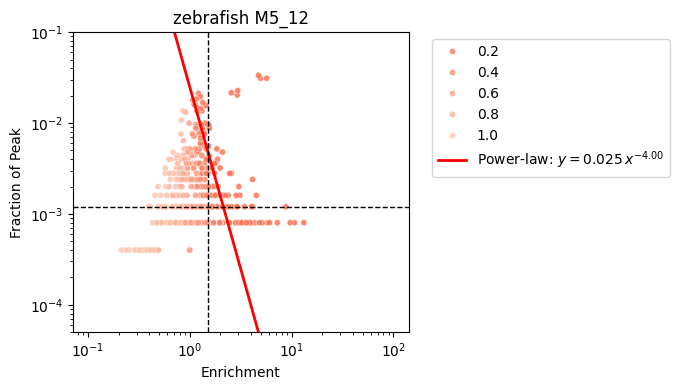

In [18]:
# --- given fit parameters ---
alpha = 4
c = 0.025

# --- choose x-range for the curve ---
x_min, x_max = 0.1, 100     # <-- you can adjust if needed
y_min, y_max = 3e-3, 1.0   # <-- adjust vertical range to match your data

# generate smooth x grid in log-space
x_line = np.logspace(np.log10(x_min), np.log10(x_max), 400)
y_line = c * (x_line ** (-alpha))



# --- plot ---
plt.figure(figsize=(7,4))
sns.scatterplot(
    data=zebra_M5_12_filtered,
    x="Enrichment",
    y="Peak",
    hue="Fisher",
    palette=cmap,
    alpha=0.8,
    s=20,
    rasterized=True
)


# overlay the power-law curve
plt.plot(x_line, y_line, lw=2, color="red",
         label=fr"Power-law: $y={c:.3g}\,x^{{-{alpha:.2f}}}$")

# set log axes + limits
plt.xscale("log")
plt.yscale("log")
plt.ylim([0.00005,0.1])

# optional threshold lines
plt.axhline(y=0.0012, color="black", linestyle="--", linewidth=1)
plt.axvline(x=1.5, color="black", linestyle="--", linewidth=1)

plt.xlabel("Enrichment")
plt.ylabel("Fraction of Peak")
plt.title("zebrafish M5_12")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
#plt.savefig("./pair_plots/zebrafish_forebrain_cooccurrence.svg", dpi=600)

plt.show()

In [19]:
zebra_M5_12_filtered_powerlaw = apply_powerlaw_threshold(
    zebra_M5_12_filtered,
    xcol="Enrichment", ycol="Peak",
    alpha=4, c=0.025,
    x_min=1.5, y_min=0.0012,
    keep="above"
)

# points that pass
zebra_M5_12_filtered_passed = zebra_M5_12_filtered_powerlaw[zebra_M5_12_filtered_powerlaw["pass_powerlaw"]]
print(f"{len(zebra_M5_12_filtered_passed)} points passed out of {len(zebra_M5_12_filtered_powerlaw)}")

41 points passed out of 2346


/tmp/ipykernel_119/2912361076.py:17: RuntimeWarning: divide by zero encountered in power
  y_cut = c * (x ** (-alpha))


### zebra 3

In [48]:
zebra_3_enrichment = pd.read_csv("../../zebrafish/interpret/da_peaks/celltype/zebrafish_3_filtered_enrichment_06_24_26_95_74motifs_overlapfiltered.tsv",sep="\t",index_col=0)
zebra_3_rawpeaks = pd.read_csv("../../zebrafish/interpret/da_peaks/celltype/zebrafish_3_rawfiltered_peakcounts.tsv",sep="\t",index_col=0)
zebra_3_fisher = pd.read_csv("../../zebrafish/interpret/da_peaks/celltype/zebrafish_3_filtered_fisher_multiple_06_24_26_95_74motifs_overlapfiltered.tsv",sep="\t",index_col=0)

In [49]:
# Raw peaks
zebra_3_rawpeaks_motif_list = list(zebra_3_rawpeaks.columns)
zebra_3_rawpeaks_long = pd.melt(zebra_3_rawpeaks, value_vars=zebra_3_rawpeaks_motif_list,value_name='Peak',ignore_index=False).reset_index()
zebra_3_rawpeaks_long[['motif_1', 'variable']] = pd.DataFrame(zebra_3_rawpeaks_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=zebra_3_rawpeaks_long.index)
zebra_3_rawpeaks_long_final = zebra_3_rawpeaks_long.drop_duplicates(subset=['motif_1','variable'])
zebra_3_rawpeaks_long_final = zebra_3_rawpeaks_long_final.reset_index(drop=True)

# Enrichment 
zebra_3_enrichment_motif_list = list(zebra_3_enrichment.columns)
zebra_3_enrichment_long = pd.melt(zebra_3_enrichment, value_vars=zebra_3_enrichment_motif_list,value_name='Enrichment',ignore_index=False).reset_index()
zebra_3_enrichment_long[['motif_1', 'variable']] = pd.DataFrame(zebra_3_enrichment_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=zebra_3_enrichment_long.index)
zebra_3_enrichment_long_final = zebra_3_enrichment_long.drop_duplicates(subset=['motif_1','variable'])
zebra_3_enrichment_long_final = zebra_3_enrichment_long_final.reset_index(drop=True)

# Fisher
zebra_3_fisher_motif_list = list(zebra_3_fisher.columns)
zebra_3_fisher_long = pd.melt(zebra_3_fisher, value_vars=zebra_3_fisher_motif_list,value_name='Fisher',ignore_index=False).reset_index()
zebra_3_fisher_long[['motif_1', 'variable']] = pd.DataFrame(zebra_3_fisher_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=zebra_3_fisher_long.index)
zebra_3_fisher_long_final = zebra_3_fisher_long.drop_duplicates(subset=['motif_1','variable'])
zebra_3_fisher_long_final.loc[zebra_3_fisher_long_final['motif_1'] == zebra_3_fisher_long_final['variable'], 'Fisher'] = 1
zebra_3_fisher_long_final = zebra_3_fisher_long_final.reset_index(drop=True)

In [50]:
zebra_3_merged = zebra_3_rawpeaks_long_final.merge(zebra_3_enrichment_long_final, on=["motif_1", "variable"], how="outer") \
            .merge(zebra_3_fisher_long_final, on=["motif_1", "variable"], how="outer") \

zebra_3_totalpeak = pd.read_csv('../../zebrafish/interpret/da_peaks/zebra_3_peaks.csv').shape[0]

zebra_3_merged['Peak'] = zebra_3_merged['Peak']/zebra_3_totalpeak
zebra_3_filtered = zebra_3_merged[zebra_3_merged["motif_1"] != zebra_3_merged["variable"]]

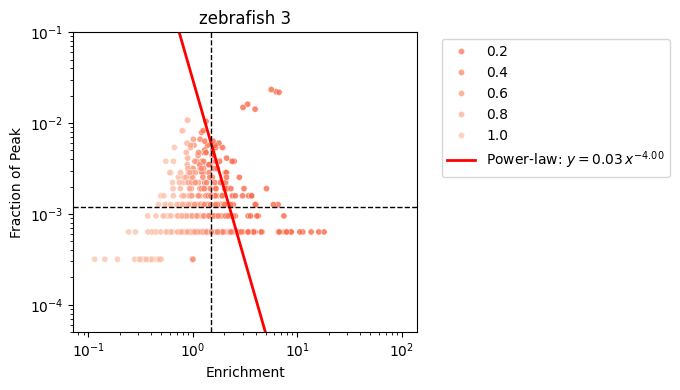

In [72]:
# --- given fit parameters ---
alpha = 4
c = 0.03

# --- choose x-range for the curve ---
x_min, x_max = 0.1, 100     # <-- you can adjust if needed
y_min, y_max = 3e-3, 1.0   # <-- adjust vertical range to match your data

# generate smooth x grid in log-space
x_line = np.logspace(np.log10(x_min), np.log10(x_max), 400)
y_line = c * (x_line ** (-alpha))



# --- plot ---
plt.figure(figsize=(7,4))
sns.scatterplot(
    data=zebra_3_filtered,
    x="Enrichment",
    y="Peak",
    hue="Fisher",
    palette=cmap,
    alpha=0.8,
    s=20,
    rasterized=True
)


# overlay the power-law curve
plt.plot(x_line, y_line, lw=2, color="red",
         label=fr"Power-law: $y={c:.3g}\,x^{{-{alpha:.2f}}}$")

# set log axes + limits
plt.xscale("log")
plt.yscale("log")
plt.ylim([0.00005,0.1])

# optional threshold lines
plt.axhline(y=0.0012, color="black", linestyle="--", linewidth=1)
plt.axvline(x=1.5, color="black", linestyle="--", linewidth=1)

plt.xlabel("Enrichment")
plt.ylabel("Fraction of Peak")
plt.title("zebrafish 3")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
#plt.savefig("./pair_plots/zebrafish_forebrain_cooccurrence.svg", dpi=600)

plt.show()

In [71]:
zebra_3_filtered_powerlaw = apply_powerlaw_threshold(
    zebra_3_filtered,
    xcol="Enrichment", ycol="Peak",
    alpha=4, c=0.03,
    x_min=1.5, y_min=0.0012,
    keep="above"
)

# points that pass
zebra_3_filtered_passed = zebra_3_filtered_powerlaw[zebra_3_filtered_powerlaw["pass_powerlaw"]]
print(f"{len(zebra_3_filtered_passed)} points passed out of {len(zebra_3_filtered_powerlaw)}")

38 points passed out of 2485


/tmp/ipykernel_20849/2912361076.py:17: RuntimeWarning: divide by zero encountered in power
  y_cut = c * (x ** (-alpha))


### zebra 10

In [20]:
zebra_10_enrichment = pd.read_csv("../../zebrafish/interpret/da_peaks/celltype/zebrafish_10_filtered_enrichment_06_24_26_95_74motifs_overlapfiltered.tsv",sep="\t",index_col=0)
zebra_10_rawpeaks = pd.read_csv("../../zebrafish/interpret/da_peaks/celltype/zebrafish_10_rawfiltered_peakcounts.tsv",sep="\t",index_col=0)
zebra_10_fisher = pd.read_csv("../../zebrafish/interpret/da_peaks/celltype/zebrafish_10_filtered_fisher_multiple_06_24_26_95_74motifs_overlapfiltered.tsv",sep="\t",index_col=0)

In [21]:
# Raw peaks
zebra_10_rawpeaks_motif_list = list(zebra_10_rawpeaks.columns)
zebra_10_rawpeaks_long = pd.melt(zebra_10_rawpeaks, value_vars=zebra_10_rawpeaks_motif_list,value_name='Peak',ignore_index=False).reset_index()
zebra_10_rawpeaks_long[['motif_1', 'variable']] = pd.DataFrame(zebra_10_rawpeaks_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=zebra_10_rawpeaks_long.index)
zebra_10_rawpeaks_long_final = zebra_10_rawpeaks_long.drop_duplicates(subset=['motif_1','variable'])
zebra_10_rawpeaks_long_final = zebra_10_rawpeaks_long_final.reset_index(drop=True)

# Enrichment 
zebra_10_enrichment_motif_list = list(zebra_10_enrichment.columns)
zebra_10_enrichment_long = pd.melt(zebra_10_enrichment, value_vars=zebra_10_enrichment_motif_list,value_name='Enrichment',ignore_index=False).reset_index()
zebra_10_enrichment_long[['motif_1', 'variable']] = pd.DataFrame(zebra_10_enrichment_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=zebra_10_enrichment_long.index)
zebra_10_enrichment_long_final = zebra_10_enrichment_long.drop_duplicates(subset=['motif_1','variable'])
zebra_10_enrichment_long_final = zebra_10_enrichment_long_final.reset_index(drop=True)

# Fisher
zebra_10_fisher_motif_list = list(zebra_10_fisher.columns)
zebra_10_fisher_long = pd.melt(zebra_10_fisher, value_vars=zebra_10_fisher_motif_list,value_name='Fisher',ignore_index=False).reset_index()
zebra_10_fisher_long[['motif_1', 'variable']] = pd.DataFrame(zebra_10_fisher_long.apply(lambda row: sorted([row['motif_1'], row['variable']]), axis=1).tolist(),
    index=zebra_10_fisher_long.index)
zebra_10_fisher_long_final = zebra_10_fisher_long.drop_duplicates(subset=['motif_1','variable'])
zebra_10_fisher_long_final.loc[zebra_10_fisher_long_final['motif_1'] == zebra_10_fisher_long_final['variable'], 'Fisher'] = 1
zebra_10_fisher_long_final = zebra_10_fisher_long_final.reset_index(drop=True)

In [22]:
zebra_10_merged = zebra_10_rawpeaks_long_final.merge(zebra_10_enrichment_long_final, on=["motif_1", "variable"], how="outer") \
            .merge(zebra_10_fisher_long_final, on=["motif_1", "variable"], how="outer") \

zebra_10_totalpeak = pd.read_csv('../../zebrafish/interpret/da_peaks/zebra_10_peaks.csv').shape[0]

zebra_10_merged['Peak'] = zebra_10_merged['Peak']/zebra_10_totalpeak
zebra_10_filtered = zebra_10_merged[zebra_10_merged["motif_1"] != zebra_10_merged["variable"]]

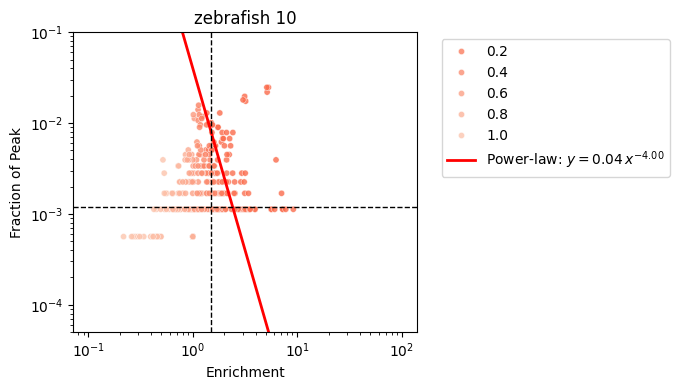

In [23]:
# --- given fit parameters ---
alpha = 4
c = 0.04

# --- choose x-range for the curve ---
x_min, x_max = 0.1, 100     # <-- you can adjust if needed
y_min, y_max = 3e-3, 1.0   # <-- adjust vertical range to match your data

# generate smooth x grid in log-space
x_line = np.logspace(np.log10(x_min), np.log10(x_max), 400)
y_line = c * (x_line ** (-alpha))



# --- plot ---
plt.figure(figsize=(7,4))
sns.scatterplot(
    data=zebra_10_filtered,
    x="Enrichment",
    y="Peak",
    hue="Fisher",
    palette=cmap,
    alpha=0.8,
    s=20,
    rasterized=True
)


# overlay the power-law curve
plt.plot(x_line, y_line, lw=2, color="red",
         label=fr"Power-law: $y={c:.3g}\,x^{{-{alpha:.2f}}}$")

# set log axes + limits
plt.xscale("log")
plt.yscale("log")
plt.ylim([0.00005,0.1])

# optional threshold lines
plt.axhline(y=0.0012, color="black", linestyle="--", linewidth=1)
plt.axvline(x=1.5, color="black", linestyle="--", linewidth=1)

plt.xlabel("Enrichment")
plt.ylabel("Fraction of Peak")
plt.title("zebrafish 10")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
#plt.savefig("./pair_plots/zebrafish_forebrain_cooccurrence.svg", dpi=600)

plt.show()

In [24]:
zebra_10_filtered_powerlaw = apply_powerlaw_threshold(
    zebra_10_filtered,
    xcol="Enrichment", ycol="Peak",
    alpha=4, c=0.04,
    x_min=1.5, y_min=0.0012,
    keep="above"
)

# points that pass
zebra_10_filtered_passed = zebra_10_filtered_powerlaw[zebra_10_filtered_powerlaw["pass_powerlaw"]]
print(f"{len(zebra_10_filtered_passed)} points passed out of {len(zebra_10_filtered_powerlaw)}")

42 points passed out of 2080


/tmp/ipykernel_119/2912361076.py:17: RuntimeWarning: divide by zero encountered in power
  y_cut = c * (x ** (-alpha))


In [39]:
## Now let's do the minimal for each brain region
len(mouse_fb_filtered_passed)

60

In [75]:
def canonicalize(df):
    # Split pair and sort to make order irrelevant
    df = df.copy()
    df["pair_key"] = df.apply(
        lambda x: "&".join(sorted([x["motif_1"], x["variable"]])),
        axis=1
    )
    return df

In [43]:
mouse_fb_filtered_passed = canonicalize(mouse_fb_filtered_passed)
zebra_fb_filtered_passed = canonicalize(zebra_fb_filtered_passed)

In [44]:
len(mouse_fb_filtered_passed)

60

In [45]:
mouse_hb_filtered_passed = canonicalize(mouse_hb_filtered_passed)
zebra_hb_filtered_passed = canonicalize(zebra_hb_filtered_passed)

In [46]:
mouse_sc_filtered_passed = canonicalize(mouse_sc_filtered_passed)
zebra_sc_filtered_passed = canonicalize(zebra_sc_filtered_passed)

In [76]:
## canonicalize cell type 
# posterior 
mouse_M1_2_filtered_passed = canonicalize(mouse_M1_2_filtered_passed)
zebra_3_filtered_passed = canonicalize(zebra_3_filtered_passed)

#optics 
mouse_4_filtered_passed = canonicalize(mouse_4_filtered_passed)
zebra_M5_12_filtered_passed = canonicalize(zebra_M5_12_filtered_passed)

#mid
mouse_0_filtered_passed = canonicalize(mouse_0_filtered_passed)
zebra_10_filtered_passed = canonicalize(zebra_10_filtered_passed)

In [77]:
common_mid = mouse_0_filtered_passed.merge(zebra_10_filtered_passed, on="pair_key", suffixes=("_mouse", "_zebra"))
common_posterior = mouse_M1_2_filtered_passed.merge(zebra_3_filtered_passed, on="pair_key", suffixes=("_mouse", "_zebra"))
common_optics = mouse_4_filtered_passed.merge(zebra_M5_12_filtered_passed, on="pair_key", suffixes=("_mouse", "_zebra"))


In [47]:
common_fb = mouse_fb_filtered_passed.merge(zebra_fb_filtered_passed, on="pair_key", suffixes=("_mouse", "_zebra"))
common_hb = mouse_hb_filtered_passed.merge(zebra_hb_filtered_passed, on="pair_key", suffixes=("_mouse", "_zebra"))
common_sc = mouse_sc_filtered_passed.merge(zebra_sc_filtered_passed, on="pair_key", suffixes=("_mouse", "_zebra"))


In [48]:
## Now making the histogram for cooccurrence
data = {
    "species_group": ["mouse", "mouse", "mouse",
                      "zebrafish", "zebrafish", "zebrafish",
                      "shared", "shared", "shared"],
    "region": ["forebrain", "hindbrain", "spinal cord"] * 3,
    "n_pairs": [len(mouse_fb_filtered_passed), len(mouse_hb_filtered_passed), len(mouse_sc_filtered_passed),   # example numbers for mouse
                len(zebra_fb_filtered_passed), len(zebra_hb_filtered_passed), len(zebra_sc_filtered_passed),   # zebrafish
                len(common_fb),  len(common_hb), len(common_sc)]   # shared
}

df_counts = pd.DataFrame(data)

In [49]:
df_counts

,species_group,region,n_pairs
0,mouse,forebrain,60
1,mouse,hindbrain,79
2,mouse,spinal cord,64
3,zebrafish,forebrain,64
4,zebrafish,hindbrain,73
5,zebrafish,spinal cord,82
6,shared,forebrain,6
7,shared,hindbrain,5
8,shared,spinal cord,5


In [78]:
## Now making the histogram for cooccurrence
data = {
    "species_group": ["mouse", "mouse", "mouse",
                      "zebrafish", "zebrafish", "zebrafish",
                      "shared", "shared", "shared"],
    "celltype": ["optics", "mid", "posterior"] * 3,
    "n_pairs": [len(mouse_4_filtered_passed), len(mouse_0_filtered_passed), len(mouse_M1_2_filtered_passed),   # example numbers for mouse
                len(zebra_M5_12_filtered_passed), len(zebra_10_filtered_passed), len(zebra_3_filtered_passed),   # zebrafish
                len(common_optics),  len(common_mid), len(common_posterior)]   # shared
}

df_counts = pd.DataFrame(data)

In [79]:
df_counts

,species_group,celltype,n_pairs
0,mouse,optics,58
1,mouse,mid,57
2,mouse,posterior,38
3,zebrafish,optics,41
4,zebrafish,mid,42
5,zebrafish,posterior,38
6,shared,optics,3
7,shared,mid,7
8,shared,posterior,0


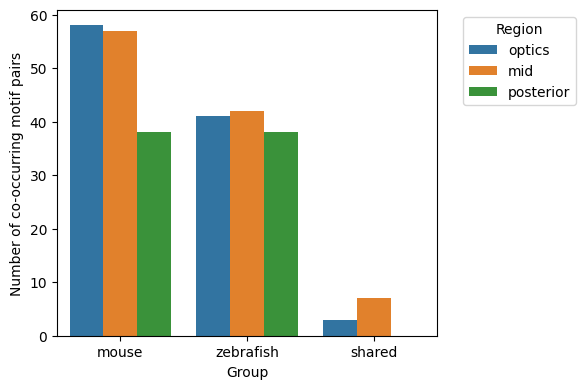

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure ordering on the x-axis
df_counts["species_group"] = pd.Categorical(
    df_counts["species_group"],
    categories=["mouse", "zebrafish", "shared"],
    ordered=True
)

df_counts["celltype"] = pd.Categorical(
    df_counts["celltype"],
    categories=["optics", "mid", "posterior"],
    ordered=True
)

plt.figure(figsize=(6, 4))

sns.barplot(
    data=df_counts,
    x="species_group",
    y="n_pairs",
    hue="celltype"
)

plt.xlabel("Group")
plt.ylabel("Number of co-occurring motif pairs")
plt.legend(title="Region", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("./pair_plots/mouse_zebrafish_cooccurrence_brain_celltype_updated.svg")
plt.show()

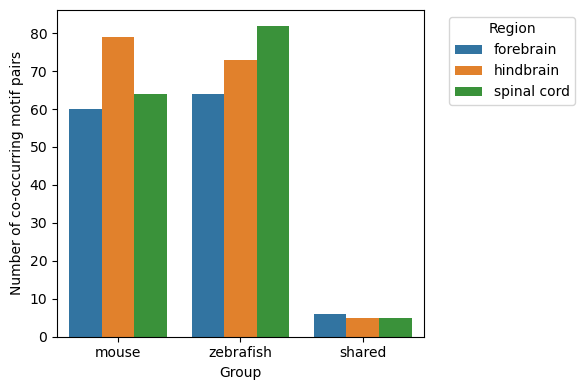

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure ordering on the x-axis
df_counts["species_group"] = pd.Categorical(
    df_counts["species_group"],
    categories=["mouse", "zebrafish", "shared"],
    ordered=True
)

df_counts["region"] = pd.Categorical(
    df_counts["region"],
    categories=["forebrain", "hindbrain", "spinal cord"],
    ordered=True
)

plt.figure(figsize=(6, 4))

sns.barplot(
    data=df_counts,
    x="species_group",
    y="n_pairs",
    hue="region"
)

plt.xlabel("Group")
plt.ylabel("Number of co-occurring motif pairs")
plt.legend(title="Region", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
#plt.savefig("./pair_plots/mouse_zebrafish_cooccurrence_brain_region_updated.svg")
plt.show()

### Making heatmap for supplementary

In [75]:
import matplotlib
import numpy as np
import matplotlib.colors as mcolors

custom_cmap1 = matplotlib.colors.LinearSegmentedColormap.from_list( '',['white',*plt.cm.Reds((np.linspace(0,1,100)**(2)))])
custom_cmap2 = matplotlib.colors.LinearSegmentedColormap.from_list( '',['white',*plt.cm.Greens((np.linspace(0,1,100)**(2)))])
custom_cmap3 = matplotlib.colors.LinearSegmentedColormap.from_list( '',['white',*plt.cm.Blues((np.linspace(0,1,100)**(2)))])


mustard_colors = [
     (1.0, 1.0, 1.0),         # white
    (1.0, 0.9, 0.5),         # golden yellow
    (0.87, 0.67, 0.0)      # deep mustard / ochre
]

# Create colormap with optional gamma correction
gamma = 2
x = np.linspace(0, 1, 100) ** gamma
custom_cmap4 = mcolors.LinearSegmentedColormap.from_list('mustard', mustard_colors)

gray_cmap = mcolors.LinearSegmentedColormap.from_list("gray_gradient", ["#eeeeee", "#000000"])


In [69]:
## This is motif order that we need to follow
flatworm_homeo = ['JC_0250|HNF1B(0.014)', 'JC_0065|HOXC4(0.160)', 'JC_0047|Dlx2(0.053)', 'JC_0069|Lim3(0.213)', 'JC_0066|NK7.1(0.157)', 'JC_0255|POU4F3(0.087)', 
                  'JC_0024|PAX6(0.000)', 'JC_0067|Lim1(0.115)', 'JC_0294|Hmx1(0.140)', 'JC_0071|oc(0.080)', 'JC_0278|POU6F1(var.2)(0.077)']

flatworm_zinc_finger = ['JC_0381|VEZF1(0.259)', 'JC_0216|eor-1(0.028)', 'JC_0412|ZNF16(0.000)', 'JC_0101|AZF1(0.282)', 'JC_0238|KLF4(0.340)', 
                        'JC_0182|ZIC4(0.145)', 'JC_0393|ZNF528(0.000)', 'JC_0418|PRDM1(0.077)']

flatworm_HMG = ['JC_0058|AHL20(0.142)', 'JC_0197|SOX4(0.087)', 'JC_0030|SOX8(0.153)']

flatworm_nuclear = []

flatworm_Rel = ['JC_0318|RELB(0.265)']

flatworm_fork = ['JC_0147|RFX1(0.285)']

flatworm_ETS = ['JC_0054|EWSR1-FLI1(0.000)']

flatworm_CRC = [] 

vertebrate_homeo = ['JC_0406|HOXA13(0.220)', 'JC_0053|Pou5f1--Sox2(0.000)', 'JC_0064|HOXD9(0.138)', 'JC_0363|DPRX(0.011)', 'JC_0293|HMBOX1(0.336)', 'JC_0251|HOXC11(0.096)', 
                    'JC_0085|NKX2-5(0.216)', 'JC_0025|MEIS1(var.2)(0.102)', 'JC_0180|POU5F1B(0.039)', 'JC_0084|vvl(0.198)', 'JC_0076|ISL2(0.233)']

vertebrate_zinc_finger = ['JC_0401|Wt1(0.209)', 'JC_0019|ZNF384(0.534)', 'JC_0022|MZF1(var.2)(0.000)', 'JC_0267|GLIS3(0.143)', 'JC_0028|RREB1(0.047)', 'JC_0354|PLAGL2(0.130)',
                          'JC_0041|Znf423(0.000)', 'JC_0050|ZNF354C(0.000)', 'JC_0365|GLI3(0.045)', 'JC_0042|Macho-1(0.349)', 'JC_0321|ZNF282(0.022)', 'JC_0270|ZNF410(0.027)', 
                          'JC_0237|HIC2(0.248)', 'JC_0211|blmp-1(0.450)', 'JC_0188|Gfi1b(0.144)', 'JC_0160|PRDM4(0.281)', 'JC_0387|ZNF136(0.000)', 'JC_0402|Zic1--Zic2(0.079)',
                          'JC_0428|Clamp(0.000)']

vertebrate_HMG = ['JC_0377|SOX14(0.213)', 'JC_0291|Sox1(0.279)', 'JC_0378|SOX18(0.038)', 'JC_0209|pan(0.000)', 'JC_0292|Sox11(0.000)']

vertebrate_nuclear = ['JC_0007|usp(0.031)', 'JC_0061|RARA(var.2)(0.372)', 'JC_0029|NR1I2(0.361)', 'JC_0373|NR1D2(0.085)', 'JC_0122|NFIX(0.219)', 
                      'JC_0063|Nr2e3(0.000)', 'JC_0208|NR1H4(0.465)', 'JC_0376|RARB(var.3)(0.065)']

vertebrate_Rel = ['JC_0275|NFKB2(0.067)', 'JC_0059|NFATC1(0.123)']

vertebrate_fork = ['JC_0272|E2F8(0.075)', 'JC_0187|FOXH1(0.039)']

vertebrate_ETS = ['JC_0353|IRF3(0.049)']

vertebrate_CRC = ['JC_0241|LIN54(0.314)']

final_order = flatworm_homeo + flatworm_zinc_finger + flatworm_HMG + flatworm_nuclear + flatworm_Rel + flatworm_fork + flatworm_ETS + flatworm_CRC + \
              vertebrate_homeo + vertebrate_zinc_finger + vertebrate_HMG  + vertebrate_nuclear + vertebrate_Rel + vertebrate_fork + \
              vertebrate_ETS + vertebrate_CRC 

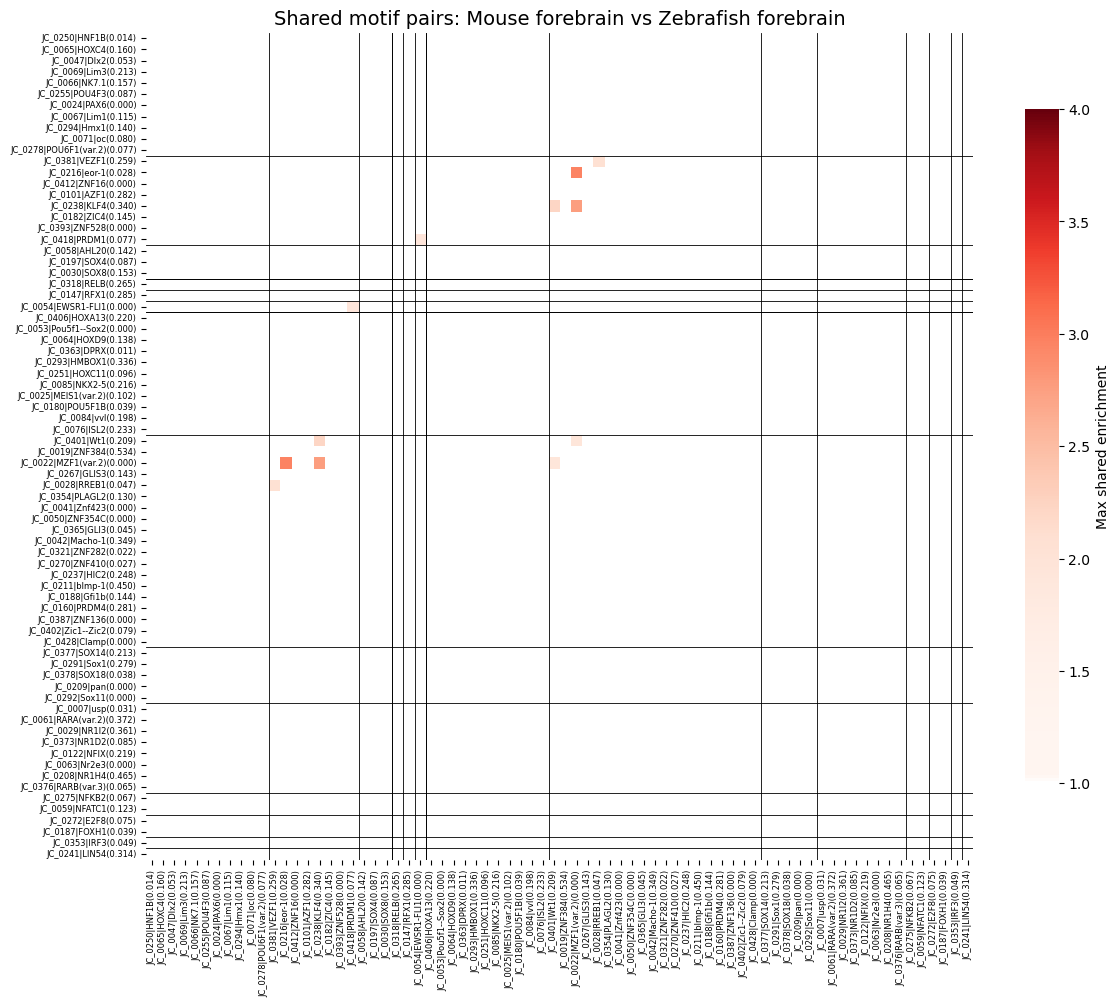

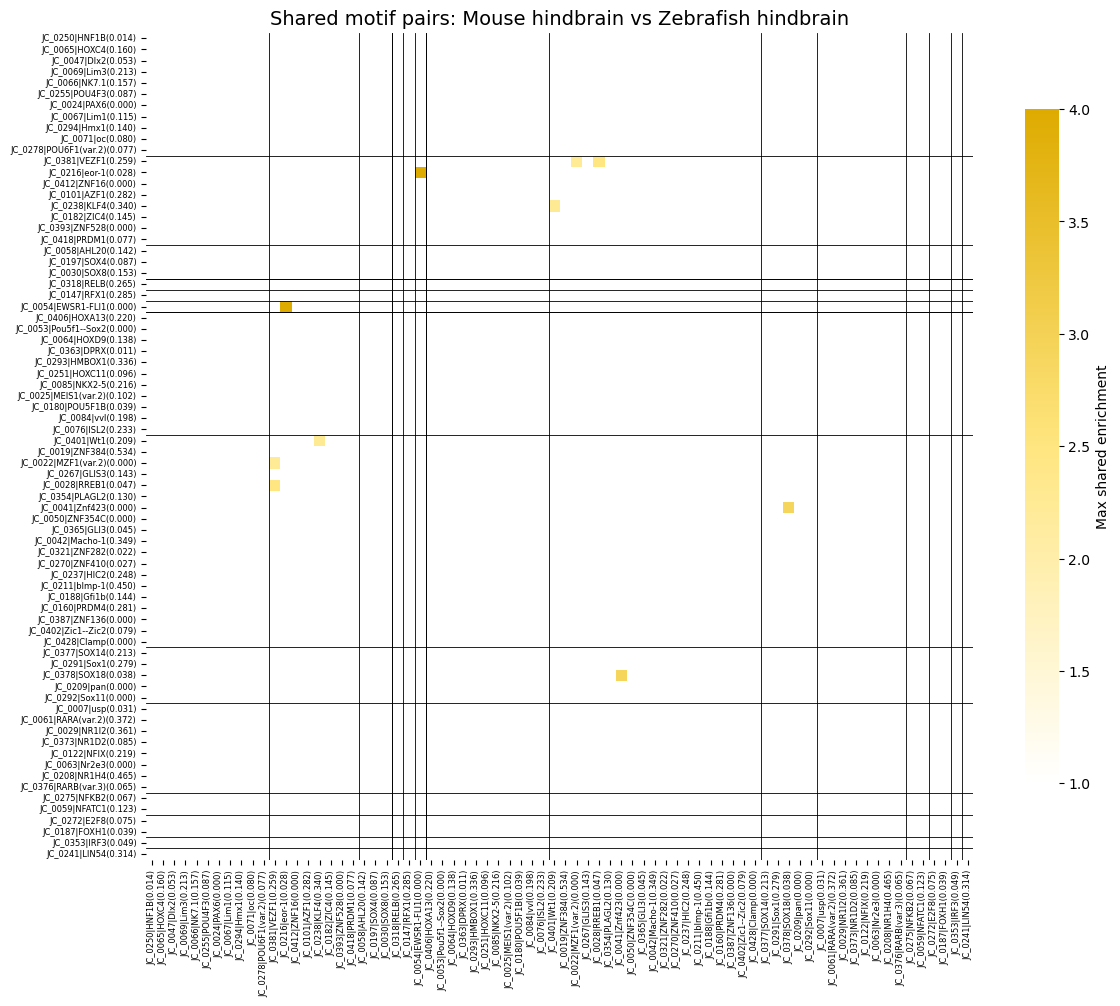

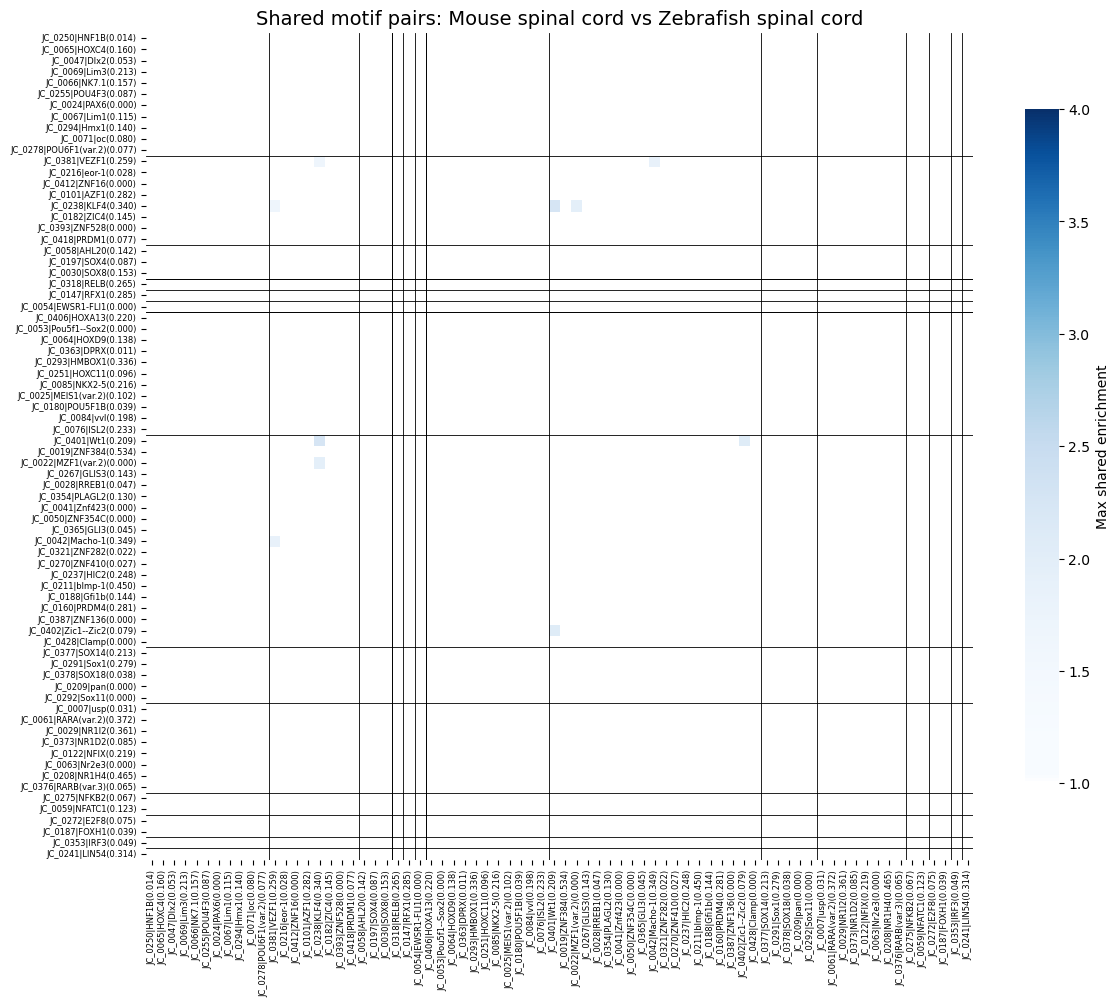

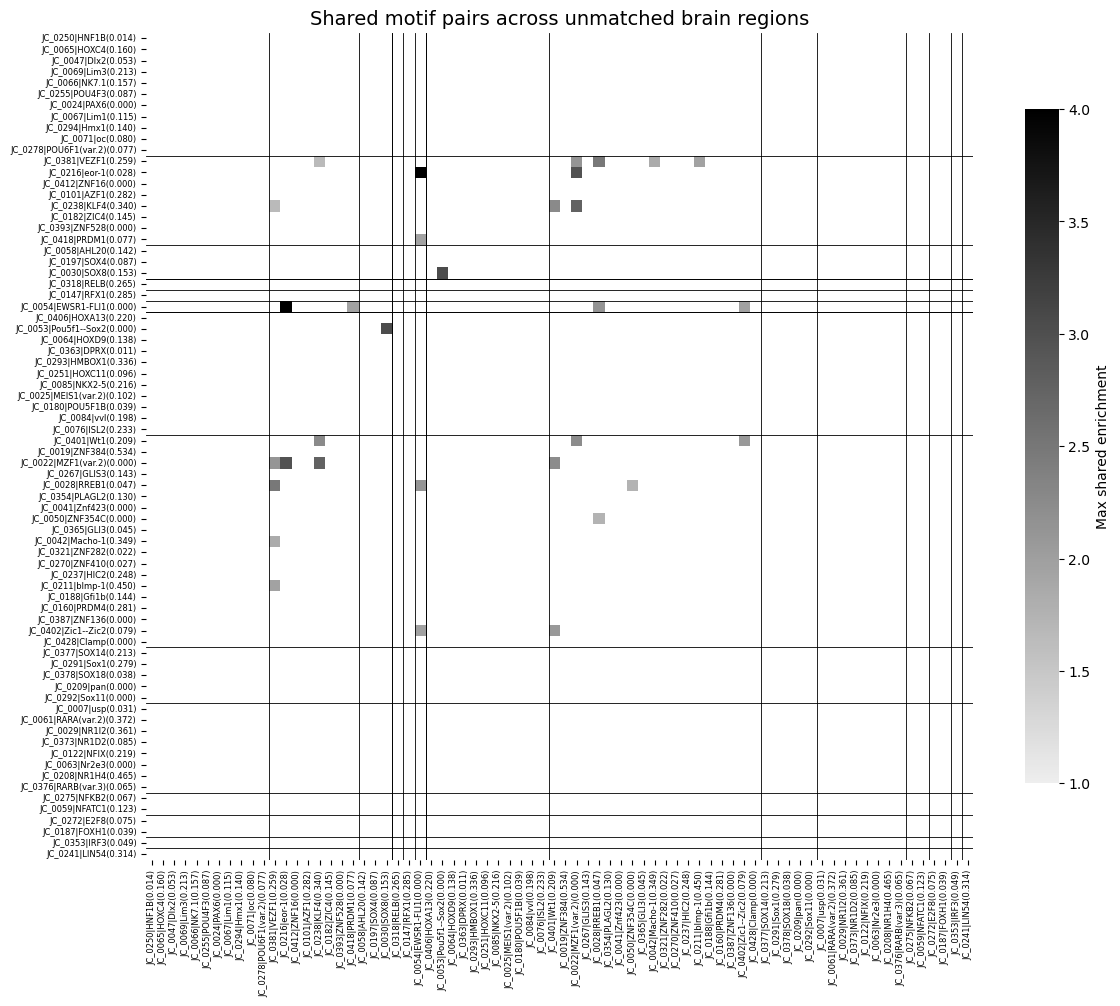

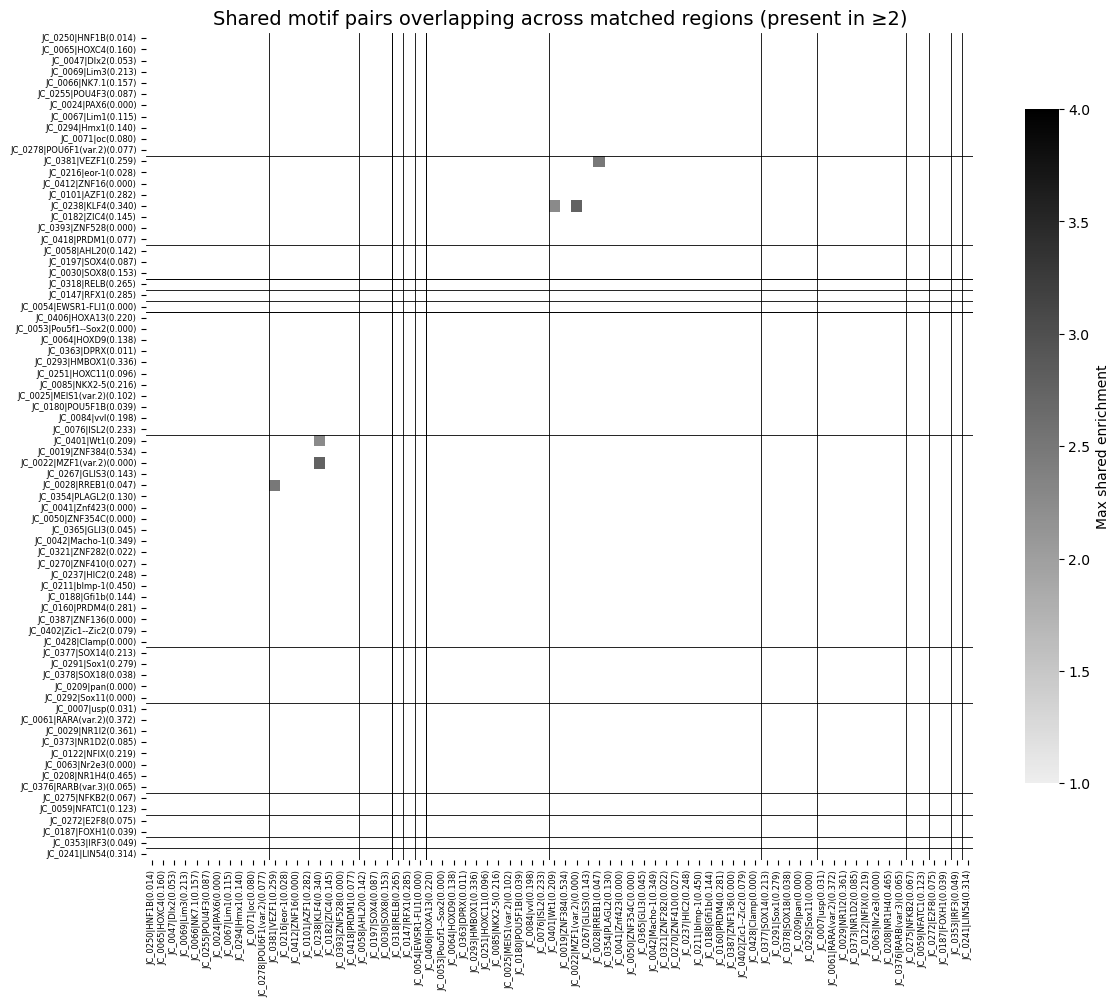

In [118]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.colors as mcolors
import matplotlib as mpl

# =========================================================
# OPTIONAL: keep SVG text editable
# =========================================================
mpl.rcParams["svg.fonttype"] = "none"

# =========================================================
# REQUIRED INPUTS
# =========================================================
# You should already have these 6 dataframes in memory:
#   mouse_fb, mouse_hb, mouse_sc
#   zebra_fb, zebra_hb, zebra_sc
#
# Each dataframe must contain these columns:
#   motif_1, variable, Enrichment
#
# You should also already have:
#   final_order
#
# And these motif group lists for boundary lines:
#   flatworm_homeo, flatworm_zinc_finger, flatworm_HMG, flatworm_nuclear,
#   flatworm_Rel, flatworm_fork, flatworm_ETS, flatworm_CRC,
#   vertebrate_homeo, vertebrate_zinc_finger, vertebrate_HMG, vertebrate_nuclear,
#   vertebrate_Rel, vertebrate_fork, vertebrate_ETS, vertebrate_CRC


# =========================================================
# 1) REGION DICTIONARIES
# =========================================================
mouse_regions = {
    "Forebrain": mouse_fb_filtered_passed,
    "Hindbrain": mouse_hb_filtered_passed,
    "Spinal cord": mouse_sc_filtered_passed
}

zebra_regions = {
    "Forebrain": zebra_fb_filtered_passed,
    "Hindbrain": zebra_hb_filtered_passed,
    "Spinal cord": zebra_fb_filtered_passed
}


# =========================================================
# 2) CUSTOM COLORMAPS
# =========================================================

# Forebrain
custom_cmap1 = matplotlib.colors.LinearSegmentedColormap.from_list(
    "",
    ["white", *plt.cm.Reds((np.linspace(0, 1, 100) ** 2))]
)

# Hindbrain
mustard_colors = [
    (1.0, 1.0, 1.0),
    (1.0, 0.9, 0.5),
    (0.87, 0.67, 0.0)
]
custom_cmap4 = mcolors.LinearSegmentedColormap.from_list(
    "mustard",
    mustard_colors,
    N=256
)

# Spinal cord
custom_cmap3 = matplotlib.colors.LinearSegmentedColormap.from_list(
    "",
    ["white", *plt.cm.Blues((np.linspace(0, 1, 100) ** 2))]
)

# Gray
gray_cmap = mcolors.LinearSegmentedColormap.from_list(
    "gray_gradient",
    ["#eeeeee", "#000000"]
)


# =========================================================
# 3) BLOCK BOUNDARIES
# =========================================================
group_sizes = [
    len(flatworm_homeo),
    len(flatworm_zinc_finger),
    len(flatworm_HMG),
    len(flatworm_nuclear),
    len(flatworm_Rel),
    len(flatworm_fork),
    len(flatworm_ETS),
    len(flatworm_CRC),
    len(vertebrate_homeo),
    len(vertebrate_zinc_finger),
    len(vertebrate_HMG),
    len(vertebrate_nuclear),
    len(vertebrate_Rel),
    len(vertebrate_fork),
    len(vertebrate_ETS),
    len(vertebrate_CRC),
]
boundaries = np.cumsum(group_sizes)


# =========================================================
# 4) HELPER: CANONICALIZE UNORDERED PAIRS
# =========================================================
def canonicalize_pairs(df, final_order):
    order_index = {m: i for i, m in enumerate(final_order)}

    sub = df.loc[
        df["motif_1"].isin(final_order) & df["variable"].isin(final_order),
        ["motif_1", "variable", "Enrichment"]
    ].copy()

    sub["i1"] = sub["motif_1"].map(order_index)
    sub["i2"] = sub["variable"].map(order_index)

    sub["motif_a"] = np.where(
        sub["i1"] <= sub["i2"],
        sub["motif_1"],
        sub["variable"]
    )
    sub["motif_b"] = np.where(
        sub["i1"] <= sub["i2"],
        sub["variable"],
        sub["motif_1"]
    )

    sub = (
        sub.groupby(["motif_a", "motif_b"], as_index=False)["Enrichment"]
        .max()
    )

    return sub


# =========================================================
# 5) HELPER: SHARED PAIRS BETWEEN TWO REGION DATAFRAMES
# =========================================================
def shared_pairs_between_two_regions(
    df_mouse,
    df_zebra,
    final_order,
    mouse_region,
    zebra_region
):
    m_pairs = canonicalize_pairs(df_mouse, final_order).rename(
        columns={"Enrichment": "Enrichment_mouse"}
    )
    z_pairs = canonicalize_pairs(df_zebra, final_order).rename(
        columns={"Enrichment": "Enrichment_zebra"}
    )

    shared = pd.merge(
        m_pairs,
        z_pairs,
        on=["motif_a", "motif_b"],
        how="inner"
    )

    out_cols = [
        "motif_a", "motif_b",
        "Enrichment_mouse", "Enrichment_zebra",
        "shared_enrichment", "comparison",
        "mouse_region", "zebra_region"
    ]

    if shared.empty:
        return pd.DataFrame(columns=out_cols)

    shared["shared_enrichment"] = shared[
        ["Enrichment_mouse", "Enrichment_zebra"]
    ].max(axis=1)

    shared["mouse_region"] = mouse_region
    shared["zebra_region"] = zebra_region

    shared["comparison"] = (
        f"mouse_{mouse_region.lower().replace(' ', '_')}"
        f"__zebra_{zebra_region.lower().replace(' ', '_')}"
    )

    return shared[out_cols]


# =========================================================
# 6) HELPER: CONVERT SHARED TABLE TO MATRIX
# =========================================================
def shared_df_to_matrix(shared_df, final_order, value_col="shared_enrichment", vmax_cap=4):
    mat = pd.DataFrame(
        np.nan,
        index=final_order,
        columns=final_order,
        dtype=float
    )

    if not shared_df.empty:
        summary = (
            shared_df.groupby(["motif_a", "motif_b"], as_index=False)[value_col]
            .max()
        )

        for _, row in summary.iterrows():
            a = row["motif_a"]
            b = row["motif_b"]
            val = row[value_col]

            mat.loc[a, b] = val
            mat.loc[b, a] = val

    np.fill_diagonal(mat.values, np.nan)
    mat = mat.clip(upper=vmax_cap)
    return mat


# =========================================================
# 7) BUILD THE MATCHED-REGION SHARED TABLES
# =========================================================
shared_fb_fb = shared_pairs_between_two_regions(
    mouse_regions["Forebrain"],
    zebra_regions["Forebrain"],
    final_order,
    mouse_region="Forebrain",
    zebra_region="Forebrain"
)

shared_hb_hb = shared_pairs_between_two_regions(
    mouse_regions["Hindbrain"],
    zebra_regions["Hindbrain"],
    final_order,
    mouse_region="Hindbrain",
    zebra_region="Hindbrain"
)

shared_sc_sc = shared_pairs_between_two_regions(
    mouse_regions["Spinal cord"],
    zebra_regions["Spinal cord"],
    final_order,
    mouse_region="Spinal cord",
    zebra_region="Spinal cord"
)


# =========================================================
# 8) BUILD ACROSS-REGION SHARED TABLE
# =========================================================
region_names = ["Forebrain", "Hindbrain", "Spinal cord"]
across_list = []

for m_region in region_names:
    for z_region in region_names:
        if m_region == z_region:
            continue

        tmp = shared_pairs_between_two_regions(
            mouse_regions[m_region],
            zebra_regions[z_region],
            final_order,
            mouse_region=m_region,
            zebra_region=z_region
        )

        if not tmp.empty:
            across_list.append(tmp)

if len(across_list) > 0:
    shared_across = pd.concat(across_list, ignore_index=True)
else:
    shared_across = pd.DataFrame(columns=[
        "motif_a", "motif_b",
        "Enrichment_mouse", "Enrichment_zebra",
        "shared_enrichment", "comparison",
        "mouse_region", "zebra_region"
    ])


# =========================================================
# 9) BUILD OVERLAP OF MATCHED REGIONS
#    Keep motif pairs present in at least 2 of:
#    shared_fb_fb, shared_hb_hb, shared_sc_sc
# =========================================================
matched_list = []

for df_tmp, label in [
    (shared_fb_fb, "mouse_forebrain__zebra_forebrain"),
    (shared_hb_hb, "mouse_hindbrain__zebra_hindbrain"),
    (shared_sc_sc, "mouse_spinal_cord__zebra_spinal_cord"),
]:
    if not df_tmp.empty:
        tmp = df_tmp.copy()
        tmp["matched_comparison"] = label
        matched_list.append(tmp)

if len(matched_list) > 0:
    shared_matched_all = pd.concat(matched_list, ignore_index=True)
else:
    shared_matched_all = pd.DataFrame(columns=[
        "motif_a", "motif_b",
        "Enrichment_mouse", "Enrichment_zebra",
        "shared_enrichment", "comparison",
        "mouse_region", "zebra_region",
        "matched_comparison"
    ])

if not shared_matched_all.empty:
    shared_matched_overlap = (
        shared_matched_all.groupby(["motif_a", "motif_b"], as_index=False)
        .agg(
            n_matched_comparisons=("matched_comparison", "nunique"),
            shared_enrichment=("shared_enrichment", "max"),
            matched_comparisons=("matched_comparison", lambda x: ",".join(sorted(set(x))))
        )
    )
    shared_matched_overlap = shared_matched_overlap.loc[
        shared_matched_overlap["n_matched_comparisons"] >= 2
    ].copy()
else:
    shared_matched_overlap = pd.DataFrame(columns=[
        "motif_a", "motif_b",
        "n_matched_comparisons",
        "shared_enrichment",
        "matched_comparisons"
    ])


# =========================================================
# 10) BUILD MATRICES
# =========================================================
mat_fb_fb = shared_df_to_matrix(
    shared_fb_fb,
    final_order,
    value_col="shared_enrichment",
    vmax_cap=4
)

mat_hb_hb = shared_df_to_matrix(
    shared_hb_hb,
    final_order,
    value_col="shared_enrichment",
    vmax_cap=4
)

mat_sc_sc = shared_df_to_matrix(
    shared_sc_sc,
    final_order,
    value_col="shared_enrichment",
    vmax_cap=4
)

mat_across = shared_df_to_matrix(
    shared_across,
    final_order,
    value_col="shared_enrichment",
    vmax_cap=4
)

mat_matched_overlap = shared_df_to_matrix(
    shared_matched_overlap,
    final_order,
    value_col="shared_enrichment",
    vmax_cap=4
)


# =========================================================
# 11) PLOTTING HELPER
# =========================================================
def plot_one_heatmap(
    mat,
    title,
    out_prefix,
    boundaries,
    cmap,
    vmin=1,
    vmax=4,
    figsize=(12, 12),
    xtick_fontsize=6,
    ytick_fontsize=6,
    linecolor="black",
    linewidth=0.6,
):
    mask = mat.isna()

    plt.figure(figsize=figsize, facecolor="none")

    ax = sns.heatmap(
        mat,
        cmap=cmap,
        mask=mask,
        vmin=vmin,
        vmax=vmax,
        square=True,
        xticklabels=True,
        yticklabels=True,
        cbar_kws={"label": "Max shared enrichment", "shrink": 0.6}
    )

    ax.set_facecolor("none")

    for b in boundaries:
        ax.axhline(b, color=linecolor, lw=linewidth)
        ax.axvline(b, color=linecolor, lw=linewidth)

    plt.xticks(rotation=90, fontsize=xtick_fontsize)
    plt.yticks(rotation=0, fontsize=ytick_fontsize)
    plt.title(title, fontsize=14)
    plt.tight_layout()

    plt.savefig(f"{out_prefix}.svg", transparent=True, bbox_inches="tight")
    plt.savefig(f"{out_prefix}.pdf", transparent=True, bbox_inches="tight")
    plt.show()


# =========================================================
# 12) PLOT THE 5 HEATMAPS
# =========================================================

# 1. Forebrain ↔ Forebrain
plot_one_heatmap(
    mat=mat_fb_fb,
    title="Shared motif pairs: Mouse forebrain vs Zebrafish forebrain",
    out_prefix="heatmap_forebrain_forebrain",
    boundaries=boundaries,
    cmap=custom_cmap1,
    vmin=1,
    vmax=4
)

# 2. Hindbrain ↔ Hindbrain
plot_one_heatmap(
    mat=mat_hb_hb,
    title="Shared motif pairs: Mouse hindbrain vs Zebrafish hindbrain",
    out_prefix="heatmap_hindbrain_hindbrain",
    boundaries=boundaries,
    cmap=custom_cmap4,
    vmin=1,
    vmax=4
)

# 3. Spinal cord ↔ Spinal cord
plot_one_heatmap(
    mat=mat_sc_sc,
    title="Shared motif pairs: Mouse spinal cord vs Zebrafish spinal cord",
    out_prefix="heatmap_spinalcord_spinalcord",
    boundaries=boundaries,
    cmap=custom_cmap3,
    vmin=1,
    vmax=4
)

# 4. Across unmatched brain regions
plot_one_heatmap(
    mat=mat_across,
    title="Shared motif pairs across unmatched brain regions",
    out_prefix="heatmap_across_brain_regions",
    boundaries=boundaries,
    cmap=custom_cmap2,
    vmin=1,
    vmax=4
)

# 5. Overlap across matched regions (present in at least 2 of FB-FB / HB-HB / SC-SC)
plot_one_heatmap(
    mat=mat_matched_overlap,
    title="Shared motif pairs overlapping across matched regions (present in ≥2)",
    out_prefix="heatmap_overlap_matched_regions",
    boundaries=boundaries,
    cmap=gray_cmap,
    vmin=1,
    vmax=4
)